In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import random
import cv2
import sys
import gc
import os
import time
import warnings
import copy

from sklearn.metrics import accuracy_score, confusion_matrix

In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable, detect_anomaly
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid

from PIL import Image, ImageOps, ImageEnhance

In [108]:
from sklearn.model_selection import KFold

In [109]:
train_size = len(os.listdir("../../data/train/"))
test_size = len(os.listdir("../../data/test/"))
print(f"学習データの枚数: {train_size}")
print(f"テストデータの枚数: {test_size}")

学習データの枚数: 60000
テストデータの枚数: 10000


In [110]:
seeds = 777
torch.manual_seed(seeds)
random.seed(seeds)
np.random.seed(seeds)
torch.cuda.manual_seed(seeds)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

# 適当な画像を確認

In [111]:
image = Image.open(os.path.join('../../data/train', 'train_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [112]:
image = Image.open(os.path.join('../../data/train', 'train_12.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [113]:
image = Image.open(os.path.join('../../data/test', 'test_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


それぞれ画像の大きさは横×縦が28×28で, グレースケール画像であることが確認できました.

学習用画像データにおけるそれぞれの数字の分布をみてみます.

In [114]:
train_master = pd.read_csv("../../assets/train_master.csv")
train_master.head()

,file_name,category_id
0,train_0.jpg,5
1,train_1.jpg,0
2,train_2.jpg,4
3,train_3.jpg,1
4,train_4.jpg,9


In [115]:
train_master['category_id'].value_counts().sort_index()

category_id
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

# 手法
次に実際にモデリングを行い, 評価用画像データに対して予測をできるようにします.

今回はLeNetの畳み込みステムを活用し、Capsule Network (CapsNet) に **K分割交差検証（K-Fold Cross Validation）** と **アーリーストッピング（Early Stopping）** を適用してモデリングを試みます.

実装はpytorchを用います.

まず60,000枚の学習用画像データを読み込みます. その際, あらかじめデータの数値の範囲が[0, 1]となるように正規化しておきます.

pytorchではモデルに学習データを渡す際は(サンプル数, チャンネル数, 縦, 横)の形でなければならないので, そのように変形しておきます.

# DataLoader

In [116]:
class MNIST_data(Dataset):
    """MNIST dtaa set"""

    def __init__(self, data, mode, transform=None):

        self.df = data
        self.tsfm = transform
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name, label = self.df.loc[idx, "file_name"], self.df.loc[idx, "category_id"]
        if self.mode == "train":
            image = cv2.imread(f"../../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        else:
            image = cv2.imread(f"../../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        return image, label

In [117]:
transform_train = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])
transform_test = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])

In [118]:
sample = MNIST_data(train_master, mode="train", transform=transform_train)
sample_loader = torch.utils.data.DataLoader(dataset=sample, batch_size=16, shuffle=True, worker_init_fn=seeds)

確認

In [119]:
images, labels = next(iter(sample_loader))

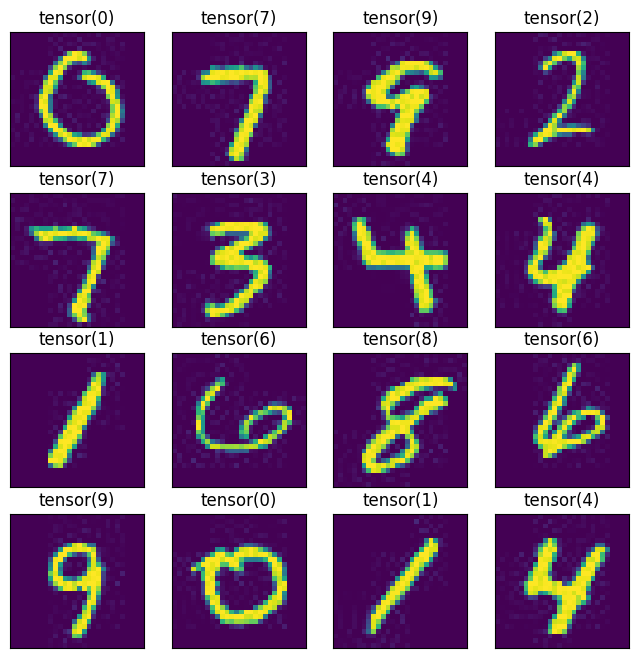

In [120]:
plt.figure(figsize=(8,8))
for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(label)
    plt.xticks(())
    plt.yticks(())
plt.show()

# Model作成&損失関数設定

In [121]:
class LeNet(nn.Module):
    def __init__(self, output_size=10, activation='relu'):
        super(LeNet, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, output_size)

        # 活性化関数の辞書
        self.activations = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh
        }

    def forward(self, x):
        act_func = self.activations.get(self.activation, F.relu)
        x = self.pool(act_func(self.conv1(x)))
        x = self.pool(act_func(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = act_func(self.fc1(x))
        x = act_func(self.fc2(x))
        x = self.fc3(x)
        return x


def squash(tensor, dim=-1):
    """
    カプセルのスカッシュ関数
    ベクトルの長さを0-1の範囲に正規化する
    """
    squared_norm = (tensor ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1 + squared_norm)
    return scale * tensor / torch.sqrt(squared_norm + 1e-8)


class PrimaryCaps(nn.Module):
    """
    Primary Capsule Layer
    畳み込み層の出力をカプセル表現に変換
    """
    def __init__(self, in_channels, out_channels, dim_caps, kernel_size, stride=1, padding=0):
        super(PrimaryCaps, self).__init__()
        self.dim_caps = dim_caps
        self.conv = nn.Conv2d(in_channels, out_channels * dim_caps, 
                             kernel_size=kernel_size, stride=stride, padding=padding)
    
    def forward(self, x):
        # x: [batch_size, in_channels, H, W]
        out = self.conv(x)  # [batch_size, out_channels*dim_caps, H', W']
        batch_size = out.size(0)
        
        # カプセル形状に変換: [batch_size, num_caps, dim_caps]
        out = out.view(batch_size, -1, self.dim_caps)
        
        # スカッシュ関数を適用
        return squash(out)


class DigitCaps(nn.Module):
    """
    Digit Capsule Layer (Dynamic Routing)
    各クラスに対応するカプセルを生成
    """
    def __init__(self, in_num_caps, in_dim_caps, out_num_caps, out_dim_caps, num_routing=3):
        super(DigitCaps, self).__init__()
        self.in_num_caps = in_num_caps
        self.in_dim_caps = in_dim_caps
        self.out_num_caps = out_num_caps
        self.out_dim_caps = out_dim_caps
        self.num_routing = num_routing
        
        # 変換行列: [1, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps]
        self.W = nn.Parameter(torch.randn(1, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps))
    
    def forward(self, x):
        # x: [batch_size, in_num_caps, in_dim_caps]
        batch_size = x.size(0)
        
        # x を拡張: [batch_size, in_num_caps, 1, in_dim_caps, 1]
        x = x.unsqueeze(2).unsqueeze(4)
        
        # W を拡張: [batch_size, in_num_caps, out_num_caps, out_dim_caps, in_dim_caps]
        W = self.W.repeat(batch_size, 1, 1, 1, 1)
        
        # u_hat = W @ x: [batch_size, in_num_caps, out_num_caps, out_dim_caps, 1]
        u_hat = torch.matmul(W, x)
        u_hat = u_hat.squeeze(4)  # [batch_size, in_num_caps, out_num_caps, out_dim_caps]
        
        # Dynamic Routing
        b = torch.zeros(batch_size, self.in_num_caps, self.out_num_caps, 1).to(x.device)
        
        for iteration in range(self.num_routing):
            # Softmax over out_num_caps dimension
            c = F.softmax(b, dim=2)  # [batch_size, in_num_caps, out_num_caps, 1]
            
            # s = sum(c * u_hat): [batch_size, out_num_caps, out_dim_caps]
            s = (c * u_hat).sum(dim=1)
            
            # v = squash(s): [batch_size, out_num_caps, out_dim_caps]
            v = squash(s, dim=-1)
            
            # 最後のiterationでは b を更新しない
            if iteration < self.num_routing - 1:
                # b を更新: [batch_size, in_num_caps, out_num_caps, 1]
                v_expanded = v.unsqueeze(1)  # [batch_size, 1, out_num_caps, out_dim_caps]
                agreement = (u_hat * v_expanded).sum(dim=-1, keepdim=True)
                b = b + agreement
        
        return v  # [batch_size, out_num_caps, out_dim_caps]


class CapsNet(nn.Module):
    """
    Capsule Network
    LeNetの畳み込みステムを再利用し、CapsuleレイヤーでMNIST分類を行う
    """
    def __init__(self, output_size=10, activation='relu'):
        super(CapsNet, self).__init__()
        self.activation = activation
        
        # LeNetの畳み込みステムを再利用
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # 活性化関数の辞書
        self.activations = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh
        }
        
        # Primary Capsule Layer
        # 入力: 16チャンネル, 4x4の特徴マップ
        # 出力: 32個のカプセル, 各カプセルは8次元
        self.primary_caps = PrimaryCaps(in_channels=16, out_channels=32, 
                                       dim_caps=8, kernel_size=3, stride=1, padding=0)
        
        # Digit Capsule Layer (Dynamic Routing)
        # Primary Capsの出力サイズを計算: (4-3+0)/1+1 = 2
        # -> 32 * 2 * 2 = 128個のカプセル
        self.digit_caps = DigitCaps(in_num_caps=128, in_dim_caps=8,
                                    out_num_caps=output_size, out_dim_caps=16,
                                    num_routing=3)
    
    def forward(self, x):
        # LeNetの畳み込みステムを通す
        act_func = self.activations.get(self.activation, F.relu)
        x = self.pool(act_func(self.conv1(x)))  # [batch, 6, 12, 12]
        x = self.pool(act_func(self.conv2(x)))  # [batch, 16, 4, 4]
        
        # Primary Capsule Layer
        x = self.primary_caps(x)  # [batch, 128, 8]
        
        # Digit Capsule Layer
        x = self.digit_caps(x)  # [batch, 10, 16]
        
        # カプセルの長さを計算(クラススコア)
        x = torch.sqrt((x ** 2).sum(dim=-1))  # [batch, 10]
        
        return x

# アーリーストッピング（Early Stopping）クラス

In [122]:
# 変更開始: アーリーストッピングクラスの追加
class EarlyStopping:
    """
    アーリーストッピング
    検証損失が改善しなくなったら学習を早期停止する
    """
    def __init__(self, patience=7, min_delta=0.0, mode='min', verbose=True):
        """
        Args:
            patience (int): 何エポック改善しなかったら停止するか
            min_delta (float): 改善とみなす最小の変化量
            mode (str): 'min'（損失）または 'max'（精度）
            verbose (bool): メッセージを表示するか
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, score, model):
        """
        Args:
            score (float): 検証損失または検証精度
            model (nn.Module): PyTorchモデル
        """
        # 初回
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
            if self.verbose:
                print(f'初期値: {score:.4f}')
            return
        
        # 改善したかチェック
        if self.mode == 'min':
            improved = score < (self.best_score - self.min_delta)
        else:  # mode == 'max'
            improved = score > (self.best_score + self.min_delta)
        
        if improved:
            if self.verbose:
                print(f'検証スコアが改善: {self.best_score:.4f} → {score:.4f}')
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience} (最良: {self.best_score:.4f})')
            
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f'アーリーストッピング発動！')
    
    def save_checkpoint(self, model):
        """最良モデルの重みを保存"""
        self.best_model_state = copy.deepcopy(model.state_dict())
    
    def load_best_model(self, model):
        """最良モデルの重みを復元"""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
        return model
# 変更ここまで

In [123]:
criterion = nn.CrossEntropyLoss()

# K-Fold交差検証の設定

In [124]:
N_FOLDS = 5
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seeds)
print(f"{N_FOLDS}分割交差検証を実行します")

5分割交差検証を実行します


# 訓練

In [125]:
#GPUを使うか使わないか(使う場合cudaになり、使わない場合cpuとなる)
device = ""

if torch.cuda.is_available():
    device = "cuda"

if torch.backends.mps.is_available():
    device = "mps"

if device == "":
    device = "cpu"
    
print(f"使用デバイス: {device}")

使用デバイス: cuda


In [126]:
batch_size = 64
EPOCH = 100  # 最大エポック数（アーリーストッピングで早期終了する可能性あり）
PATIENCE = 10  # アーリーストッピングの patience

In [127]:
# 変更開始: アーリーストッピングを組み込んだ学習関数
def training_validation_fold(input_model, optimizer, EPOCH, training_data, validation_data, fold_num, patience=10):
    """1つのfoldに対する学習と検証を実行（アーリーストッピング付き）"""
    total_batch = int(len(training_data)/12)
    
    # 履歴を記録するリスト
    history = {
        'train_loss': [],
        'valid_loss': [],
        'valid_accuracy': [],
        'stopped_epoch': None
    }
    
    # アーリーストッピングの初期化（検証損失を監視）
    early_stopping = EarlyStopping(patience=patience, min_delta=0.0001, mode='min', verbose=True)
    
    print(f"\n{'='*60}")
    print(f"Fold {fold_num}/{N_FOLDS} の学習を開始")
    print(f"アーリーストッピング: patience={patience}")
    print(f"{'='*60}")
    
    for epoch in range(1, EPOCH+1):
        input_model.train()
        #訓練プロセス
        train_loss = []
        pbar = tqdm.tqdm(enumerate(training_data), total = len(training_data), 
                        desc=f"Fold {fold_num} Epoch {epoch}/{EPOCH}")
        for process, (images, labels) in pbar:
            images = images.to(device)
            labels = labels.to(device)
            outputs = input_model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss = loss.item()
            train_loss.append(loss)
            if (process % total_batch == 0) | (process == len(training_data)):
                pbar.set_postfix(train_loss=np.mean(train_loss))

        #検証プロセス
        input_model.eval()
        valid_loss = []
        correct = 0
        with torch.no_grad():
            for images, labels in validation_data:
                images = images.to(device)
                labels = labels.to(device)
                outputs = input_model(images)
                loss = criterion(outputs, labels)
                valid_loss.append(loss.item())
                pred = outputs.data.max(1, keepdim=True)[1]
                correct += pred.eq(labels.data.view_as(pred)).cpu().sum().item()
        
        # エポックごとの結果を記録
        epoch_train_loss = np.mean(train_loss)
        epoch_valid_loss = np.mean(valid_loss)
        epoch_valid_accuracy = correct/len(validation_data.dataset)
        
        history['train_loss'].append(epoch_train_loss)
        history['valid_loss'].append(epoch_valid_loss)
        history['valid_accuracy'].append(epoch_valid_accuracy)
        
        print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, valid_loss={epoch_valid_loss:.4f}, valid_accuracy={epoch_valid_accuracy:.4f}")
        
        # アーリーストッピングのチェック
        early_stopping(epoch_valid_loss, input_model)
        
        if early_stopping.early_stop:
            print(f"\nEpoch {epoch} でアーリーストッピング発動")
            history['stopped_epoch'] = epoch
            break
    
    # 最良モデルの重みを復元
    input_model = early_stopping.load_best_model(input_model)
    print(f"\n最良モデル（検証損失: {early_stopping.best_score:.4f}）を復元しました")

    return input_model, history
# 変更ここまで

In [128]:
# 予測結果のそれぞれの誤差の大きさを確認
def predict_img(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    test_proba = torch.FloatTensor()
    with torch.no_grad():
        for images, labels in tqdm.tqdm(input_data):
            images = images.to(device)
            labels = labels.to(device)
            outputs = input_model(images)
            pred_proba = F.softmax(outputs, dim=1).cpu()
            pred = outputs.data.max(1, keepdim=True)[1].view(-1)
            pred = torch.stack([labels,pred],axis=1).cpu()
            test_pred = torch.cat((test_pred, pred), dim=0)
            test_proba = torch.cat((test_proba, pred_proba), dim=0)
    test_pred = test_pred.cpu().detach().numpy()
    test_proba = test_proba.cpu().detach().numpy()
    loss_correct = np.array(pd.get_dummies(test_pred[:,0]))
    test_loss = -(loss_correct*np.log(test_proba+1e-07)).sum(axis=1)
    test_pred = pd.DataFrame(test_pred).rename(columns = {0:"label" ,1:"predict"})
    test_proba = pd.DataFrame(test_proba).rename(columns = {0:"proba_0", 1:"proba_1", 2:"proba_2", 3:"proba_3", 4:"proba_4",
                                                            5:"proba_5", 6:"proba_6", 7:"proba_7", 8:"proba_8", 9:"proba_9"})
    test_loss = pd.DataFrame(test_loss).rename(columns = {0:"loss"})
    df = pd.concat([test_pred, test_proba, test_loss], axis=1)
    del loss_correct
    gc.collect()
    return df

## K-Fold交差検証の実行

In [129]:
# K-Fold交差検証のメインループ
fold_results = []
fold_models = []

for fold, (train_idx, valid_idx) in enumerate(kfold.split(train_master), 1):
    # Foldごとにデータを分割
    train_fold = train_master.iloc[train_idx].reset_index(drop=True)
    valid_fold = train_master.iloc[valid_idx].reset_index(drop=True)
    
    # DataLoaderを作成
    train_data = MNIST_data(train_fold, mode="train", transform=transform_train)
    valid_data = MNIST_data(valid_fold, mode="train", transform=transform_test)
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, worker_init_fn=seeds)
    valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size)
    
    # モデルとオプティマイザーを初期化
    model = CapsNet(output_size=10, activation='relu').to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # 学習と検証を実行（アーリーストッピング付き）
    model, history = training_validation_fold(model, optimizer, EPOCH, train_loader, valid_loader, fold, patience=PATIENCE)
    
    # 結果を保存
    fold_results.append({
        'fold': fold,
        'history': history,
        'best_valid_acc': max(history['valid_accuracy']),
        'final_valid_acc': history['valid_accuracy'][-1],
        'final_valid_loss': history['valid_loss'][-1],
        'stopped_epoch': history['stopped_epoch'] if history['stopped_epoch'] else EPOCH
    })
    fold_models.append(model)
    
    # メモリ解放
    del train_loader, valid_loader, train_data, valid_data
    gc.collect()
    
print(f"\n{'='*60}")
print("K-Fold交差検証完了")
print(f"{'='*60}")


Fold 1/5 の学習を開始
アーリーストッピング: patience=10


Fold 1 Epoch 1/100:   1%|▏         | 11/750 [00:00<00:42, 17.41it/s, train_loss=2.29]

Fold 1 Epoch 1/100: 100%|██████████| 750/750 [00:19<00:00, 38.75it/s, train_loss=1.6] 


Epoch 1: train_loss=1.6010, valid_loss=1.5213, valid_accuracy=0.9735
初期値: 1.5213


Fold 1 Epoch 2/100: 100%|██████████| 750/750 [00:08<00:00, 85.43it/s, train_loss=1.51]


Epoch 2: train_loss=1.5091, valid_loss=1.5018, valid_accuracy=0.9802
検証スコアが改善: 1.5213 → 1.5018


Fold 1 Epoch 3/100: 100%|██████████| 750/750 [00:09<00:00, 80.69it/s, train_loss=1.5]


Epoch 3: train_loss=1.4965, valid_loss=1.4956, valid_accuracy=0.9821
検証スコアが改善: 1.5018 → 1.4956


Fold 1 Epoch 4/100: 100%|██████████| 750/750 [00:07<00:00, 97.49it/s, train_loss=1.49] 


Epoch 4: train_loss=1.4894, valid_loss=1.4889, valid_accuracy=0.9848
検証スコアが改善: 1.4956 → 1.4889


Fold 1 Epoch 5/100: 100%|██████████| 750/750 [00:09<00:00, 78.11it/s, train_loss=1.49]


Epoch 5: train_loss=1.4856, valid_loss=1.4838, valid_accuracy=0.9878
検証スコアが改善: 1.4889 → 1.4838


Fold 1 Epoch 6/100: 100%|██████████| 750/750 [00:09<00:00, 82.07it/s, train_loss=1.48]


Epoch 6: train_loss=1.4827, valid_loss=1.4824, valid_accuracy=0.9866
検証スコアが改善: 1.4838 → 1.4824


Fold 1 Epoch 7/100: 100%|██████████| 750/750 [00:07<00:00, 101.70it/s, train_loss=1.48]


Epoch 7: train_loss=1.4802, valid_loss=1.4814, valid_accuracy=0.9872
検証スコアが改善: 1.4824 → 1.4814


Fold 1 Epoch 8/100: 100%|██████████| 750/750 [00:09<00:00, 82.20it/s, train_loss=1.48]


Epoch 8: train_loss=1.4792, valid_loss=1.4813, valid_accuracy=0.9882
EarlyStopping counter: 1/10 (最良: 1.4814)


Fold 1 Epoch 9/100: 100%|██████████| 750/750 [00:09<00:00, 81.26it/s, train_loss=1.48]


Epoch 9: train_loss=1.4773, valid_loss=1.4832, valid_accuracy=0.9857
EarlyStopping counter: 2/10 (最良: 1.4814)


Fold 1 Epoch 10/100: 100%|██████████| 750/750 [00:07<00:00, 99.29it/s, train_loss=1.48] 


Epoch 10: train_loss=1.4766, valid_loss=1.4783, valid_accuracy=0.9889
検証スコアが改善: 1.4814 → 1.4783


Fold 1 Epoch 11/100: 100%|██████████| 750/750 [00:09<00:00, 81.79it/s, train_loss=1.48]


Epoch 11: train_loss=1.4759, valid_loss=1.4786, valid_accuracy=0.9889
EarlyStopping counter: 1/10 (最良: 1.4783)


Fold 1 Epoch 12/100: 100%|██████████| 750/750 [00:09<00:00, 82.29it/s, train_loss=1.47]


Epoch 12: train_loss=1.4748, valid_loss=1.4775, valid_accuracy=0.9889
検証スコアが改善: 1.4783 → 1.4775


Fold 1 Epoch 13/100: 100%|██████████| 750/750 [00:07<00:00, 100.41it/s, train_loss=1.47]


Epoch 13: train_loss=1.4742, valid_loss=1.4769, valid_accuracy=0.9884
検証スコアが改善: 1.4775 → 1.4769


Fold 1 Epoch 14/100: 100%|██████████| 750/750 [00:09<00:00, 82.46it/s, train_loss=1.47]


Epoch 14: train_loss=1.4741, valid_loss=1.4766, valid_accuracy=0.9886
検証スコアが改善: 1.4769 → 1.4766


Fold 1 Epoch 15/100: 100%|██████████| 750/750 [00:09<00:00, 82.03it/s, train_loss=1.47]


Epoch 15: train_loss=1.4732, valid_loss=1.4767, valid_accuracy=0.9892
EarlyStopping counter: 1/10 (最良: 1.4766)


Fold 1 Epoch 16/100: 100%|██████████| 750/750 [00:07<00:00, 101.09it/s, train_loss=1.47]


Epoch 16: train_loss=1.4726, valid_loss=1.4743, valid_accuracy=0.9917
検証スコアが改善: 1.4766 → 1.4743


Fold 1 Epoch 17/100: 100%|██████████| 750/750 [00:09<00:00, 82.65it/s, train_loss=1.47]


Epoch 17: train_loss=1.4726, valid_loss=1.4767, valid_accuracy=0.9878
EarlyStopping counter: 1/10 (最良: 1.4743)


Fold 1 Epoch 18/100: 100%|██████████| 750/750 [00:09<00:00, 80.85it/s, train_loss=1.47]


Epoch 18: train_loss=1.4718, valid_loss=1.4757, valid_accuracy=0.9895
EarlyStopping counter: 2/10 (最良: 1.4743)


Fold 1 Epoch 19/100: 100%|██████████| 750/750 [00:07<00:00, 101.47it/s, train_loss=1.47]


Epoch 19: train_loss=1.4715, valid_loss=1.4773, valid_accuracy=0.9879
EarlyStopping counter: 3/10 (最良: 1.4743)


Fold 1 Epoch 20/100: 100%|██████████| 750/750 [00:09<00:00, 82.42it/s, train_loss=1.47]


Epoch 20: train_loss=1.4713, valid_loss=1.4739, valid_accuracy=0.9899
検証スコアが改善: 1.4743 → 1.4739


Fold 1 Epoch 21/100: 100%|██████████| 750/750 [00:09<00:00, 81.31it/s, train_loss=1.47]


Epoch 21: train_loss=1.4717, valid_loss=1.4757, valid_accuracy=0.9883
EarlyStopping counter: 1/10 (最良: 1.4739)


Fold 1 Epoch 22/100: 100%|██████████| 750/750 [00:07<00:00, 100.52it/s, train_loss=1.47]


Epoch 22: train_loss=1.4707, valid_loss=1.4730, valid_accuracy=0.9911
検証スコアが改善: 1.4739 → 1.4730


Fold 1 Epoch 23/100: 100%|██████████| 750/750 [00:09<00:00, 82.12it/s, train_loss=1.47]


Epoch 23: train_loss=1.4707, valid_loss=1.4732, valid_accuracy=0.9909
EarlyStopping counter: 1/10 (最良: 1.4730)


Fold 1 Epoch 24/100: 100%|██████████| 750/750 [00:09<00:00, 82.03it/s, train_loss=1.47]


Epoch 24: train_loss=1.4705, valid_loss=1.4744, valid_accuracy=0.9896
EarlyStopping counter: 2/10 (最良: 1.4730)


Fold 1 Epoch 25/100: 100%|██████████| 750/750 [00:07<00:00, 94.70it/s, train_loss=1.47]


Epoch 25: train_loss=1.4704, valid_loss=1.4761, valid_accuracy=0.9894
EarlyStopping counter: 3/10 (最良: 1.4730)


Fold 1 Epoch 26/100: 100%|██████████| 750/750 [00:09<00:00, 80.68it/s, train_loss=1.47]


Epoch 26: train_loss=1.4701, valid_loss=1.4733, valid_accuracy=0.9901
EarlyStopping counter: 4/10 (最良: 1.4730)


Fold 1 Epoch 27/100: 100%|██████████| 750/750 [00:09<00:00, 82.60it/s, train_loss=1.47]


Epoch 27: train_loss=1.4697, valid_loss=1.4784, valid_accuracy=0.9851
EarlyStopping counter: 5/10 (最良: 1.4730)


Fold 1 Epoch 28/100: 100%|██████████| 750/750 [00:07<00:00, 101.98it/s, train_loss=1.47]


Epoch 28: train_loss=1.4700, valid_loss=1.4740, valid_accuracy=0.9894
EarlyStopping counter: 6/10 (最良: 1.4730)


Fold 1 Epoch 29/100: 100%|██████████| 750/750 [00:09<00:00, 83.16it/s, train_loss=1.47]


Epoch 29: train_loss=1.4691, valid_loss=1.4724, valid_accuracy=0.9920
検証スコアが改善: 1.4730 → 1.4724


Fold 1 Epoch 30/100: 100%|██████████| 750/750 [00:09<00:00, 82.56it/s, train_loss=1.47]


Epoch 30: train_loss=1.4692, valid_loss=1.4741, valid_accuracy=0.9898
EarlyStopping counter: 1/10 (最良: 1.4724)


Fold 1 Epoch 31/100: 100%|██████████| 750/750 [00:07<00:00, 102.26it/s, train_loss=1.47]


Epoch 31: train_loss=1.4692, valid_loss=1.4725, valid_accuracy=0.9905
EarlyStopping counter: 2/10 (最良: 1.4724)


Fold 1 Epoch 32/100: 100%|██████████| 750/750 [00:09<00:00, 83.03it/s, train_loss=1.47]


Epoch 32: train_loss=1.4688, valid_loss=1.4734, valid_accuracy=0.9895
EarlyStopping counter: 3/10 (最良: 1.4724)


Fold 1 Epoch 33/100: 100%|██████████| 750/750 [00:09<00:00, 82.54it/s, train_loss=1.47]


Epoch 33: train_loss=1.4686, valid_loss=1.4727, valid_accuracy=0.9913
EarlyStopping counter: 4/10 (最良: 1.4724)


Fold 1 Epoch 34/100: 100%|██████████| 750/750 [00:07<00:00, 101.05it/s, train_loss=1.47]


Epoch 34: train_loss=1.4690, valid_loss=1.4732, valid_accuracy=0.9890
EarlyStopping counter: 5/10 (最良: 1.4724)


Fold 1 Epoch 35/100: 100%|██████████| 750/750 [00:09<00:00, 82.85it/s, train_loss=1.47]


Epoch 35: train_loss=1.4690, valid_loss=1.4744, valid_accuracy=0.9897
EarlyStopping counter: 6/10 (最良: 1.4724)


Fold 1 Epoch 36/100: 100%|██████████| 750/750 [00:09<00:00, 83.33it/s, train_loss=1.47]


Epoch 36: train_loss=1.4685, valid_loss=1.4754, valid_accuracy=0.9881
EarlyStopping counter: 7/10 (最良: 1.4724)


Fold 1 Epoch 37/100: 100%|██████████| 750/750 [00:08<00:00, 83.49it/s, train_loss=1.47]


Epoch 37: train_loss=1.4683, valid_loss=1.4740, valid_accuracy=0.9902
EarlyStopping counter: 8/10 (最良: 1.4724)


Fold 1 Epoch 38/100: 100%|██████████| 750/750 [00:09<00:00, 83.10it/s, train_loss=1.47]


Epoch 38: train_loss=1.4684, valid_loss=1.4737, valid_accuracy=0.9898
EarlyStopping counter: 9/10 (最良: 1.4724)


Fold 1 Epoch 39/100: 100%|██████████| 750/750 [00:09<00:00, 82.89it/s, train_loss=1.47]


Epoch 39: train_loss=1.4678, valid_loss=1.4733, valid_accuracy=0.9898
EarlyStopping counter: 10/10 (最良: 1.4724)
アーリーストッピング発動！

Epoch 39 でアーリーストッピング発動

最良モデル（検証損失: 1.4724）を復元しました

Fold 2/5 の学習を開始
アーリーストッピング: patience=10


Fold 2 Epoch 1/100: 100%|██████████| 750/750 [00:09<00:00, 82.08it/s, train_loss=1.6] 


Epoch 1: train_loss=1.5947, valid_loss=1.5203, valid_accuracy=0.9747
初期値: 1.5203


Fold 2 Epoch 2/100: 100%|██████████| 750/750 [00:09<00:00, 82.78it/s, train_loss=1.51]


Epoch 2: train_loss=1.5099, valid_loss=1.5093, valid_accuracy=0.9752
検証スコアが改善: 1.5203 → 1.5093


Fold 2 Epoch 3/100: 100%|██████████| 750/750 [00:09<00:00, 82.11it/s, train_loss=1.5]


Epoch 3: train_loss=1.4971, valid_loss=1.4939, valid_accuracy=0.9829
検証スコアが改善: 1.5093 → 1.4939


Fold 2 Epoch 4/100: 100%|██████████| 750/750 [00:09<00:00, 82.37it/s, train_loss=1.49]


Epoch 4: train_loss=1.4898, valid_loss=1.4903, valid_accuracy=0.9842
検証スコアが改善: 1.4939 → 1.4903


Fold 2 Epoch 5/100: 100%|██████████| 750/750 [00:09<00:00, 81.90it/s, train_loss=1.49]


Epoch 5: train_loss=1.4856, valid_loss=1.4848, valid_accuracy=0.9871
検証スコアが改善: 1.4903 → 1.4848


Fold 2 Epoch 6/100: 100%|██████████| 750/750 [00:09<00:00, 82.41it/s, train_loss=1.48]


Epoch 6: train_loss=1.4828, valid_loss=1.4860, valid_accuracy=0.9848
EarlyStopping counter: 1/10 (最良: 1.4848)


Fold 2 Epoch 7/100: 100%|██████████| 750/750 [00:09<00:00, 82.22it/s, train_loss=1.48]


Epoch 7: train_loss=1.4804, valid_loss=1.4834, valid_accuracy=0.9852
検証スコアが改善: 1.4848 → 1.4834


Fold 2 Epoch 8/100: 100%|██████████| 750/750 [00:09<00:00, 82.38it/s, train_loss=1.48]


Epoch 8: train_loss=1.4790, valid_loss=1.4808, valid_accuracy=0.9886
検証スコアが改善: 1.4834 → 1.4808


Fold 2 Epoch 9/100: 100%|██████████| 750/750 [00:09<00:00, 82.19it/s, train_loss=1.48]


Epoch 9: train_loss=1.4774, valid_loss=1.4808, valid_accuracy=0.9866
EarlyStopping counter: 1/10 (最良: 1.4808)


Fold 2 Epoch 10/100: 100%|██████████| 750/750 [00:09<00:00, 82.29it/s, train_loss=1.48]


Epoch 10: train_loss=1.4766, valid_loss=1.4783, valid_accuracy=0.9874
検証スコアが改善: 1.4808 → 1.4783


Fold 2 Epoch 11/100: 100%|██████████| 750/750 [00:07<00:00, 100.33it/s, train_loss=1.48] 


Epoch 11: train_loss=1.4758, valid_loss=1.4794, valid_accuracy=0.9871
EarlyStopping counter: 1/10 (最良: 1.4783)


Fold 2 Epoch 12/100: 100%|██████████| 750/750 [00:09<00:00, 77.46it/s, train_loss=1.47]


Epoch 12: train_loss=1.4746, valid_loss=1.4790, valid_accuracy=0.9868
EarlyStopping counter: 2/10 (最良: 1.4783)


Fold 2 Epoch 13/100: 100%|██████████| 750/750 [00:09<00:00, 82.88it/s, train_loss=1.47]


Epoch 13: train_loss=1.4743, valid_loss=1.4760, valid_accuracy=0.9902
検証スコアが改善: 1.4783 → 1.4760


Fold 2 Epoch 14/100: 100%|██████████| 750/750 [00:09<00:00, 82.25it/s, train_loss=1.47]


Epoch 14: train_loss=1.4734, valid_loss=1.4778, valid_accuracy=0.9876
EarlyStopping counter: 1/10 (最良: 1.4760)


Fold 2 Epoch 15/100: 100%|██████████| 750/750 [00:09<00:00, 82.44it/s, train_loss=1.47]


Epoch 15: train_loss=1.4732, valid_loss=1.4755, valid_accuracy=0.9897
検証スコアが改善: 1.4760 → 1.4755


Fold 2 Epoch 16/100: 100%|██████████| 750/750 [00:09<00:00, 81.61it/s, train_loss=1.47]


Epoch 16: train_loss=1.4726, valid_loss=1.4750, valid_accuracy=0.9894
検証スコアが改善: 1.4755 → 1.4750


Fold 2 Epoch 17/100: 100%|██████████| 750/750 [00:07<00:00, 101.59it/s, train_loss=1.47] 


Epoch 17: train_loss=1.4722, valid_loss=1.4759, valid_accuracy=0.9893
EarlyStopping counter: 1/10 (最良: 1.4750)


Fold 2 Epoch 18/100: 100%|██████████| 750/750 [00:09<00:00, 81.06it/s, train_loss=1.47]


Epoch 18: train_loss=1.4717, valid_loss=1.4751, valid_accuracy=0.9892
EarlyStopping counter: 2/10 (最良: 1.4750)


Fold 2 Epoch 19/100: 100%|██████████| 750/750 [00:09<00:00, 81.37it/s, train_loss=1.47]


Epoch 19: train_loss=1.4712, valid_loss=1.4760, valid_accuracy=0.9891
EarlyStopping counter: 3/10 (最良: 1.4750)


Fold 2 Epoch 20/100: 100%|██████████| 750/750 [00:07<00:00, 102.48it/s, train_loss=1.47]


Epoch 20: train_loss=1.4710, valid_loss=1.4747, valid_accuracy=0.9903
検証スコアが改善: 1.4750 → 1.4747


Fold 2 Epoch 21/100: 100%|██████████| 750/750 [00:09<00:00, 81.50it/s, train_loss=1.47]


Epoch 21: train_loss=1.4708, valid_loss=1.4756, valid_accuracy=0.9888
EarlyStopping counter: 1/10 (最良: 1.4747)


Fold 2 Epoch 22/100: 100%|██████████| 750/750 [00:09<00:00, 82.04it/s, train_loss=1.47]


Epoch 22: train_loss=1.4704, valid_loss=1.4741, valid_accuracy=0.9909
検証スコアが改善: 1.4747 → 1.4741


Fold 2 Epoch 23/100: 100%|██████████| 750/750 [00:07<00:00, 100.75it/s, train_loss=1.47]


Epoch 23: train_loss=1.4700, valid_loss=1.4741, valid_accuracy=0.9905
EarlyStopping counter: 1/10 (最良: 1.4741)


Fold 2 Epoch 24/100: 100%|██████████| 750/750 [00:09<00:00, 81.47it/s, train_loss=1.47]


Epoch 24: train_loss=1.4700, valid_loss=1.4739, valid_accuracy=0.9902
検証スコアが改善: 1.4741 → 1.4739


Fold 2 Epoch 25/100: 100%|██████████| 750/750 [00:09<00:00, 82.27it/s, train_loss=1.47]


Epoch 25: train_loss=1.4701, valid_loss=1.4766, valid_accuracy=0.9878
EarlyStopping counter: 1/10 (最良: 1.4739)


Fold 2 Epoch 26/100: 100%|██████████| 750/750 [00:07<00:00, 101.18it/s, train_loss=1.47]


Epoch 26: train_loss=1.4697, valid_loss=1.4740, valid_accuracy=0.9902
EarlyStopping counter: 2/10 (最良: 1.4739)


Fold 2 Epoch 27/100: 100%|██████████| 750/750 [00:09<00:00, 82.22it/s, train_loss=1.47]


Epoch 27: train_loss=1.4693, valid_loss=1.4740, valid_accuracy=0.9899
EarlyStopping counter: 3/10 (最良: 1.4739)


Fold 2 Epoch 28/100: 100%|██████████| 750/750 [00:09<00:00, 82.60it/s, train_loss=1.47]


Epoch 28: train_loss=1.4694, valid_loss=1.4745, valid_accuracy=0.9896
EarlyStopping counter: 4/10 (最良: 1.4739)


Fold 2 Epoch 29/100: 100%|██████████| 750/750 [00:07<00:00, 103.20it/s, train_loss=1.47]


Epoch 29: train_loss=1.4694, valid_loss=1.4728, valid_accuracy=0.9914
検証スコアが改善: 1.4739 → 1.4728


Fold 2 Epoch 30/100: 100%|██████████| 750/750 [00:09<00:00, 81.73it/s, train_loss=1.47]


Epoch 30: train_loss=1.4692, valid_loss=1.4732, valid_accuracy=0.9899
EarlyStopping counter: 1/10 (最良: 1.4728)


Fold 2 Epoch 31/100: 100%|██████████| 750/750 [00:09<00:00, 81.21it/s, train_loss=1.47]


Epoch 31: train_loss=1.4687, valid_loss=1.4732, valid_accuracy=0.9908
EarlyStopping counter: 2/10 (最良: 1.4728)


Fold 2 Epoch 32/100: 100%|██████████| 750/750 [00:07<00:00, 101.85it/s, train_loss=1.47]


Epoch 32: train_loss=1.4686, valid_loss=1.4738, valid_accuracy=0.9900
EarlyStopping counter: 3/10 (最良: 1.4728)


Fold 2 Epoch 33/100: 100%|██████████| 750/750 [00:09<00:00, 82.15it/s, train_loss=1.47]


Epoch 33: train_loss=1.4687, valid_loss=1.4722, valid_accuracy=0.9903
検証スコアが改善: 1.4728 → 1.4722


Fold 2 Epoch 34/100: 100%|██████████| 750/750 [00:09<00:00, 82.14it/s, train_loss=1.47]


Epoch 34: train_loss=1.4681, valid_loss=1.4726, valid_accuracy=0.9903
EarlyStopping counter: 1/10 (最良: 1.4722)


Fold 2 Epoch 35/100: 100%|██████████| 750/750 [00:07<00:00, 101.28it/s, train_loss=1.47]


Epoch 35: train_loss=1.4682, valid_loss=1.4738, valid_accuracy=0.9898
EarlyStopping counter: 2/10 (最良: 1.4722)


Fold 2 Epoch 36/100: 100%|██████████| 750/750 [00:09<00:00, 81.95it/s, train_loss=1.47]


Epoch 36: train_loss=1.4682, valid_loss=1.4729, valid_accuracy=0.9906
EarlyStopping counter: 3/10 (最良: 1.4722)


Fold 2 Epoch 37/100: 100%|██████████| 750/750 [00:09<00:00, 81.25it/s, train_loss=1.47]


Epoch 37: train_loss=1.4682, valid_loss=1.4738, valid_accuracy=0.9889
EarlyStopping counter: 4/10 (最良: 1.4722)


Fold 2 Epoch 38/100: 100%|██████████| 750/750 [00:07<00:00, 102.47it/s, train_loss=1.47]


Epoch 38: train_loss=1.4684, valid_loss=1.4725, valid_accuracy=0.9898
EarlyStopping counter: 5/10 (最良: 1.4722)


Fold 2 Epoch 39/100: 100%|██████████| 750/750 [00:09<00:00, 82.26it/s, train_loss=1.47]


Epoch 39: train_loss=1.4675, valid_loss=1.4723, valid_accuracy=0.9904
EarlyStopping counter: 6/10 (最良: 1.4722)


Fold 2 Epoch 40/100: 100%|██████████| 750/750 [00:09<00:00, 81.57it/s, train_loss=1.47]


Epoch 40: train_loss=1.4679, valid_loss=1.4748, valid_accuracy=0.9889
EarlyStopping counter: 7/10 (最良: 1.4722)


Fold 2 Epoch 41/100: 100%|██████████| 750/750 [00:07<00:00, 100.63it/s, train_loss=1.47]


Epoch 41: train_loss=1.4676, valid_loss=1.4726, valid_accuracy=0.9906
EarlyStopping counter: 8/10 (最良: 1.4722)


Fold 2 Epoch 42/100: 100%|██████████| 750/750 [00:09<00:00, 81.86it/s, train_loss=1.47]


Epoch 42: train_loss=1.4674, valid_loss=1.4721, valid_accuracy=0.9908
検証スコアが改善: 1.4722 → 1.4721


Fold 2 Epoch 43/100: 100%|██████████| 750/750 [00:09<00:00, 81.12it/s, train_loss=1.47]


Epoch 43: train_loss=1.4674, valid_loss=1.4728, valid_accuracy=0.9898
EarlyStopping counter: 1/10 (最良: 1.4721)


Fold 2 Epoch 44/100: 100%|██████████| 750/750 [00:07<00:00, 101.51it/s, train_loss=1.47]


Epoch 44: train_loss=1.4674, valid_loss=1.4715, valid_accuracy=0.9912
検証スコアが改善: 1.4721 → 1.4715


Fold 2 Epoch 45/100: 100%|██████████| 750/750 [00:09<00:00, 81.63it/s, train_loss=1.47]


Epoch 45: train_loss=1.4672, valid_loss=1.4730, valid_accuracy=0.9896
EarlyStopping counter: 1/10 (最良: 1.4715)


Fold 2 Epoch 46/100: 100%|██████████| 750/750 [00:09<00:00, 81.25it/s, train_loss=1.47]


Epoch 46: train_loss=1.4674, valid_loss=1.4723, valid_accuracy=0.9902
EarlyStopping counter: 2/10 (最良: 1.4715)


Fold 2 Epoch 47/100: 100%|██████████| 750/750 [00:07<00:00, 101.54it/s, train_loss=1.47]


Epoch 47: train_loss=1.4674, valid_loss=1.4724, valid_accuracy=0.9898
EarlyStopping counter: 3/10 (最良: 1.4715)


Fold 2 Epoch 48/100: 100%|██████████| 750/750 [00:09<00:00, 80.94it/s, train_loss=1.47]


Epoch 48: train_loss=1.4674, valid_loss=1.4724, valid_accuracy=0.9891
EarlyStopping counter: 4/10 (最良: 1.4715)


Fold 2 Epoch 49/100: 100%|██████████| 750/750 [00:09<00:00, 81.27it/s, train_loss=1.47]


Epoch 49: train_loss=1.4666, valid_loss=1.4717, valid_accuracy=0.9902
EarlyStopping counter: 5/10 (最良: 1.4715)


Fold 2 Epoch 50/100: 100%|██████████| 750/750 [00:07<00:00, 100.46it/s, train_loss=1.47]


Epoch 50: train_loss=1.4668, valid_loss=1.4740, valid_accuracy=0.9883
EarlyStopping counter: 6/10 (最良: 1.4715)


Fold 2 Epoch 51/100: 100%|██████████| 750/750 [00:09<00:00, 81.30it/s, train_loss=1.47]


Epoch 51: train_loss=1.4671, valid_loss=1.4756, valid_accuracy=0.9869
EarlyStopping counter: 7/10 (最良: 1.4715)


Fold 2 Epoch 52/100: 100%|██████████| 750/750 [00:09<00:00, 81.34it/s, train_loss=1.47]


Epoch 52: train_loss=1.4670, valid_loss=1.4729, valid_accuracy=0.9901
EarlyStopping counter: 8/10 (最良: 1.4715)


Fold 2 Epoch 53/100: 100%|██████████| 750/750 [00:07<00:00, 100.94it/s, train_loss=1.47]


Epoch 53: train_loss=1.4663, valid_loss=1.4717, valid_accuracy=0.9903
EarlyStopping counter: 9/10 (最良: 1.4715)


Fold 2 Epoch 54/100: 100%|██████████| 750/750 [00:09<00:00, 81.42it/s, train_loss=1.47]


Epoch 54: train_loss=1.4673, valid_loss=1.4720, valid_accuracy=0.9898
EarlyStopping counter: 10/10 (最良: 1.4715)
アーリーストッピング発動！

Epoch 54 でアーリーストッピング発動

最良モデル（検証損失: 1.4715）を復元しました

Fold 3/5 の学習を開始
アーリーストッピング: patience=10


Fold 3 Epoch 1/100: 100%|██████████| 750/750 [00:09<00:00, 81.03it/s, train_loss=1.61]


Epoch 1: train_loss=1.6047, valid_loss=1.5332, valid_accuracy=0.9738
初期値: 1.5332


Fold 3 Epoch 2/100: 100%|██████████| 750/750 [00:07<00:00, 100.15it/s, train_loss=1.52]


Epoch 2: train_loss=1.5201, valid_loss=1.5125, valid_accuracy=0.9806
検証スコアが改善: 1.5332 → 1.5125


Fold 3 Epoch 3/100: 100%|██████████| 750/750 [00:09<00:00, 81.16it/s, train_loss=1.5] 


Epoch 3: train_loss=1.5041, valid_loss=1.4986, valid_accuracy=0.9840
検証スコアが改善: 1.5125 → 1.4986


Fold 3 Epoch 4/100: 100%|██████████| 750/750 [00:09<00:00, 81.15it/s, train_loss=1.5]


Epoch 4: train_loss=1.4956, valid_loss=1.4942, valid_accuracy=0.9825
検証スコアが改善: 1.4986 → 1.4942


Fold 3 Epoch 5/100: 100%|██████████| 750/750 [00:07<00:00, 101.19it/s, train_loss=1.49]


Epoch 5: train_loss=1.4900, valid_loss=1.4880, valid_accuracy=0.9852
検証スコアが改善: 1.4942 → 1.4880


Fold 3 Epoch 6/100: 100%|██████████| 750/750 [00:09<00:00, 81.10it/s, train_loss=1.49]


Epoch 6: train_loss=1.4859, valid_loss=1.4849, valid_accuracy=0.9868
検証スコアが改善: 1.4880 → 1.4849


Fold 3 Epoch 7/100: 100%|██████████| 750/750 [00:09<00:00, 80.55it/s, train_loss=1.48]


Epoch 7: train_loss=1.4837, valid_loss=1.4832, valid_accuracy=0.9863
検証スコアが改善: 1.4849 → 1.4832


Fold 3 Epoch 8/100: 100%|██████████| 750/750 [00:07<00:00, 100.89it/s, train_loss=1.48]


Epoch 8: train_loss=1.4815, valid_loss=1.4828, valid_accuracy=0.9867
検証スコアが改善: 1.4832 → 1.4828


Fold 3 Epoch 9/100: 100%|██████████| 750/750 [00:09<00:00, 81.62it/s, train_loss=1.48]


Epoch 9: train_loss=1.4796, valid_loss=1.4818, valid_accuracy=0.9874
検証スコアが改善: 1.4828 → 1.4818


Fold 3 Epoch 10/100: 100%|██████████| 750/750 [00:09<00:00, 81.06it/s, train_loss=1.48]


Epoch 10: train_loss=1.4785, valid_loss=1.4784, valid_accuracy=0.9892
検証スコアが改善: 1.4818 → 1.4784


Fold 3 Epoch 11/100: 100%|██████████| 750/750 [00:07<00:00, 100.06it/s, train_loss=1.48]


Epoch 11: train_loss=1.4772, valid_loss=1.4785, valid_accuracy=0.9892
EarlyStopping counter: 1/10 (最良: 1.4784)


Fold 3 Epoch 12/100: 100%|██████████| 750/750 [00:09<00:00, 80.80it/s, train_loss=1.48]


Epoch 12: train_loss=1.4766, valid_loss=1.4802, valid_accuracy=0.9865
EarlyStopping counter: 2/10 (最良: 1.4784)


Fold 3 Epoch 13/100: 100%|██████████| 750/750 [00:09<00:00, 80.96it/s, train_loss=1.48]


Epoch 13: train_loss=1.4758, valid_loss=1.4779, valid_accuracy=0.9898
検証スコアが改善: 1.4784 → 1.4779


Fold 3 Epoch 14/100: 100%|██████████| 750/750 [00:07<00:00, 100.80it/s, train_loss=1.48]


Epoch 14: train_loss=1.4752, valid_loss=1.4798, valid_accuracy=0.9872
EarlyStopping counter: 1/10 (最良: 1.4779)


Fold 3 Epoch 15/100: 100%|██████████| 750/750 [00:09<00:00, 81.18it/s, train_loss=1.47]


Epoch 15: train_loss=1.4745, valid_loss=1.4759, valid_accuracy=0.9894
検証スコアが改善: 1.4779 → 1.4759


Fold 3 Epoch 16/100: 100%|██████████| 750/750 [00:09<00:00, 81.11it/s, train_loss=1.47]


Epoch 16: train_loss=1.4742, valid_loss=1.4750, valid_accuracy=0.9900
検証スコアが改善: 1.4759 → 1.4750


Fold 3 Epoch 17/100: 100%|██████████| 750/750 [00:07<00:00, 97.94it/s, train_loss=1.47] 


Epoch 17: train_loss=1.4738, valid_loss=1.4766, valid_accuracy=0.9890
EarlyStopping counter: 1/10 (最良: 1.4750)


Fold 3 Epoch 18/100: 100%|██████████| 750/750 [00:09<00:00, 80.44it/s, train_loss=1.47]


Epoch 18: train_loss=1.4736, valid_loss=1.4751, valid_accuracy=0.9893
EarlyStopping counter: 2/10 (最良: 1.4750)


Fold 3 Epoch 19/100: 100%|██████████| 750/750 [00:09<00:00, 80.97it/s, train_loss=1.47]


Epoch 19: train_loss=1.4724, valid_loss=1.4793, valid_accuracy=0.9854
EarlyStopping counter: 3/10 (最良: 1.4750)


Fold 3 Epoch 20/100: 100%|██████████| 750/750 [00:07<00:00, 100.48it/s, train_loss=1.47]


Epoch 20: train_loss=1.4725, valid_loss=1.4747, valid_accuracy=0.9898
検証スコアが改善: 1.4750 → 1.4747


Fold 3 Epoch 21/100: 100%|██████████| 750/750 [00:09<00:00, 81.83it/s, train_loss=1.47]


Epoch 21: train_loss=1.4722, valid_loss=1.4763, valid_accuracy=0.9898
EarlyStopping counter: 1/10 (最良: 1.4747)


Fold 3 Epoch 22/100: 100%|██████████| 750/750 [00:09<00:00, 81.27it/s, train_loss=1.47]


Epoch 22: train_loss=1.4718, valid_loss=1.4748, valid_accuracy=0.9897
EarlyStopping counter: 2/10 (最良: 1.4747)


Fold 3 Epoch 23/100: 100%|██████████| 750/750 [00:07<00:00, 100.69it/s, train_loss=1.47]


Epoch 23: train_loss=1.4720, valid_loss=1.4746, valid_accuracy=0.9896
検証スコアが改善: 1.4747 → 1.4746


Fold 3 Epoch 24/100: 100%|██████████| 750/750 [00:09<00:00, 80.71it/s, train_loss=1.47]


Epoch 24: train_loss=1.4715, valid_loss=1.4747, valid_accuracy=0.9883
EarlyStopping counter: 1/10 (最良: 1.4746)


Fold 3 Epoch 25/100: 100%|██████████| 750/750 [00:09<00:00, 81.26it/s, train_loss=1.47]


Epoch 25: train_loss=1.4709, valid_loss=1.4750, valid_accuracy=0.9902
EarlyStopping counter: 2/10 (最良: 1.4746)


Fold 3 Epoch 26/100: 100%|██████████| 750/750 [00:07<00:00, 100.93it/s, train_loss=1.47]


Epoch 26: train_loss=1.4711, valid_loss=1.4734, valid_accuracy=0.9911
検証スコアが改善: 1.4746 → 1.4734


Fold 3 Epoch 27/100: 100%|██████████| 750/750 [00:09<00:00, 81.41it/s, train_loss=1.47]


Epoch 27: train_loss=1.4707, valid_loss=1.4737, valid_accuracy=0.9912
EarlyStopping counter: 1/10 (最良: 1.4734)


Fold 3 Epoch 28/100: 100%|██████████| 750/750 [00:09<00:00, 81.14it/s, train_loss=1.47]


Epoch 28: train_loss=1.4706, valid_loss=1.4734, valid_accuracy=0.9909
EarlyStopping counter: 2/10 (最良: 1.4734)


Fold 3 Epoch 29/100: 100%|██████████| 750/750 [00:07<00:00, 99.95it/s, train_loss=1.47] 


Epoch 29: train_loss=1.4702, valid_loss=1.4743, valid_accuracy=0.9904
EarlyStopping counter: 3/10 (最良: 1.4734)


Fold 3 Epoch 30/100: 100%|██████████| 750/750 [00:09<00:00, 80.82it/s, train_loss=1.47]


Epoch 30: train_loss=1.4706, valid_loss=1.4733, valid_accuracy=0.9902
EarlyStopping counter: 4/10 (最良: 1.4734)


Fold 3 Epoch 31/100: 100%|██████████| 750/750 [00:09<00:00, 81.03it/s, train_loss=1.47]


Epoch 31: train_loss=1.4700, valid_loss=1.4736, valid_accuracy=0.9908
EarlyStopping counter: 5/10 (最良: 1.4734)


Fold 3 Epoch 32/100: 100%|██████████| 750/750 [00:07<00:00, 100.22it/s, train_loss=1.47]


Epoch 32: train_loss=1.4697, valid_loss=1.4731, valid_accuracy=0.9909
検証スコアが改善: 1.4734 → 1.4731


Fold 3 Epoch 33/100: 100%|██████████| 750/750 [00:09<00:00, 81.72it/s, train_loss=1.47]


Epoch 33: train_loss=1.4697, valid_loss=1.4744, valid_accuracy=0.9894
EarlyStopping counter: 1/10 (最良: 1.4731)


Fold 3 Epoch 34/100: 100%|██████████| 750/750 [00:09<00:00, 81.43it/s, train_loss=1.47]


Epoch 34: train_loss=1.4697, valid_loss=1.4730, valid_accuracy=0.9909
EarlyStopping counter: 2/10 (最良: 1.4731)


Fold 3 Epoch 35/100: 100%|██████████| 750/750 [00:07<00:00, 100.39it/s, train_loss=1.47]


Epoch 35: train_loss=1.4699, valid_loss=1.4738, valid_accuracy=0.9898
EarlyStopping counter: 3/10 (最良: 1.4731)


Fold 3 Epoch 36/100: 100%|██████████| 750/750 [00:09<00:00, 81.48it/s, train_loss=1.47]


Epoch 36: train_loss=1.4688, valid_loss=1.4729, valid_accuracy=0.9903
検証スコアが改善: 1.4731 → 1.4729


Fold 3 Epoch 37/100: 100%|██████████| 750/750 [00:09<00:00, 81.14it/s, train_loss=1.47]


Epoch 37: train_loss=1.4692, valid_loss=1.4720, valid_accuracy=0.9911
検証スコアが改善: 1.4729 → 1.4720


Fold 3 Epoch 38/100: 100%|██████████| 750/750 [00:07<00:00, 99.96it/s, train_loss=1.47] 


Epoch 38: train_loss=1.4697, valid_loss=1.4732, valid_accuracy=0.9909
EarlyStopping counter: 1/10 (最良: 1.4720)


Fold 3 Epoch 39/100: 100%|██████████| 750/750 [00:09<00:00, 81.08it/s, train_loss=1.47]


Epoch 39: train_loss=1.4688, valid_loss=1.4732, valid_accuracy=0.9898
EarlyStopping counter: 2/10 (最良: 1.4720)


Fold 3 Epoch 40/100: 100%|██████████| 750/750 [00:09<00:00, 81.13it/s, train_loss=1.47]


Epoch 40: train_loss=1.4688, valid_loss=1.4736, valid_accuracy=0.9908
EarlyStopping counter: 3/10 (最良: 1.4720)


Fold 3 Epoch 41/100: 100%|██████████| 750/750 [00:07<00:00, 101.00it/s, train_loss=1.47]


Epoch 41: train_loss=1.4690, valid_loss=1.4740, valid_accuracy=0.9902
EarlyStopping counter: 4/10 (最良: 1.4720)


Fold 3 Epoch 42/100: 100%|██████████| 750/750 [00:09<00:00, 81.53it/s, train_loss=1.47]


Epoch 42: train_loss=1.4687, valid_loss=1.4738, valid_accuracy=0.9903
EarlyStopping counter: 5/10 (最良: 1.4720)


Fold 3 Epoch 43/100: 100%|██████████| 750/750 [00:09<00:00, 79.81it/s, train_loss=1.47]


Epoch 43: train_loss=1.4686, valid_loss=1.4734, valid_accuracy=0.9905
EarlyStopping counter: 6/10 (最良: 1.4720)


Fold 3 Epoch 44/100: 100%|██████████| 750/750 [00:07<00:00, 100.63it/s, train_loss=1.47]


Epoch 44: train_loss=1.4686, valid_loss=1.4735, valid_accuracy=0.9901
EarlyStopping counter: 7/10 (最良: 1.4720)


Fold 3 Epoch 45/100: 100%|██████████| 750/750 [00:09<00:00, 80.57it/s, train_loss=1.47]


Epoch 45: train_loss=1.4683, valid_loss=1.4720, valid_accuracy=0.9913
EarlyStopping counter: 8/10 (最良: 1.4720)


Fold 3 Epoch 46/100: 100%|██████████| 750/750 [00:09<00:00, 80.08it/s, train_loss=1.47]


Epoch 46: train_loss=1.4684, valid_loss=1.4721, valid_accuracy=0.9906
EarlyStopping counter: 9/10 (最良: 1.4720)


Fold 3 Epoch 47/100: 100%|██████████| 750/750 [00:07<00:00, 100.18it/s, train_loss=1.47]


Epoch 47: train_loss=1.4680, valid_loss=1.4720, valid_accuracy=0.9906
EarlyStopping counter: 10/10 (最良: 1.4720)
アーリーストッピング発動！

Epoch 47 でアーリーストッピング発動

最良モデル（検証損失: 1.4720）を復元しました

Fold 4/5 の学習を開始
アーリーストッピング: patience=10


Fold 4 Epoch 1/100: 100%|██████████| 750/750 [00:09<00:00, 80.99it/s, train_loss=1.6] 


Epoch 1: train_loss=1.6011, valid_loss=1.5286, valid_accuracy=0.9740
初期値: 1.5286


Fold 4 Epoch 2/100: 100%|██████████| 750/750 [00:09<00:00, 81.45it/s, train_loss=1.51]


Epoch 2: train_loss=1.5142, valid_loss=1.5070, valid_accuracy=0.9798
検証スコアが改善: 1.5286 → 1.5070


Fold 4 Epoch 3/100: 100%|██████████| 750/750 [00:07<00:00, 99.66it/s, train_loss=1.5] 


Epoch 3: train_loss=1.4975, valid_loss=1.4951, valid_accuracy=0.9817
検証スコアが改善: 1.5070 → 1.4951


Fold 4 Epoch 4/100: 100%|██████████| 750/750 [00:09<00:00, 80.69it/s, train_loss=1.49]


Epoch 4: train_loss=1.4896, valid_loss=1.4886, valid_accuracy=0.9848
検証スコアが改善: 1.4951 → 1.4886


Fold 4 Epoch 5/100: 100%|██████████| 750/750 [00:09<00:00, 80.72it/s, train_loss=1.48]


Epoch 5: train_loss=1.4850, valid_loss=1.4848, valid_accuracy=0.9871
検証スコアが改善: 1.4886 → 1.4848


Fold 4 Epoch 6/100: 100%|██████████| 750/750 [00:07<00:00, 100.69it/s, train_loss=1.48]


Epoch 6: train_loss=1.4818, valid_loss=1.4812, valid_accuracy=0.9887
検証スコアが改善: 1.4848 → 1.4812


Fold 4 Epoch 7/100: 100%|██████████| 750/750 [00:09<00:00, 80.74it/s, train_loss=1.48]


Epoch 7: train_loss=1.4802, valid_loss=1.4814, valid_accuracy=0.9882
EarlyStopping counter: 1/10 (最良: 1.4812)


Fold 4 Epoch 8/100: 100%|██████████| 750/750 [00:09<00:00, 81.43it/s, train_loss=1.48]


Epoch 8: train_loss=1.4782, valid_loss=1.4814, valid_accuracy=0.9866
EarlyStopping counter: 2/10 (最良: 1.4812)


Fold 4 Epoch 9/100: 100%|██████████| 750/750 [00:07<00:00, 102.03it/s, train_loss=1.48]


Epoch 9: train_loss=1.4774, valid_loss=1.4781, valid_accuracy=0.9896
検証スコアが改善: 1.4812 → 1.4781


Fold 4 Epoch 10/100: 100%|██████████| 750/750 [00:09<00:00, 81.40it/s, train_loss=1.48]


Epoch 10: train_loss=1.4767, valid_loss=1.4776, valid_accuracy=0.9893
検証スコアが改善: 1.4781 → 1.4776


Fold 4 Epoch 11/100: 100%|██████████| 750/750 [00:09<00:00, 80.93it/s, train_loss=1.48]


Epoch 11: train_loss=1.4751, valid_loss=1.4779, valid_accuracy=0.9891
EarlyStopping counter: 1/10 (最良: 1.4776)


Fold 4 Epoch 12/100: 100%|██████████| 750/750 [00:07<00:00, 100.97it/s, train_loss=1.47]


Epoch 12: train_loss=1.4744, valid_loss=1.4772, valid_accuracy=0.9888
検証スコアが改善: 1.4776 → 1.4772


Fold 4 Epoch 13/100: 100%|██████████| 750/750 [00:09<00:00, 81.25it/s, train_loss=1.47]


Epoch 13: train_loss=1.4740, valid_loss=1.4760, valid_accuracy=0.9906
検証スコアが改善: 1.4772 → 1.4760


Fold 4 Epoch 14/100: 100%|██████████| 750/750 [00:09<00:00, 81.85it/s, train_loss=1.47]


Epoch 14: train_loss=1.4733, valid_loss=1.4758, valid_accuracy=0.9898
検証スコアが改善: 1.4760 → 1.4758


Fold 4 Epoch 15/100: 100%|██████████| 750/750 [00:07<00:00, 102.80it/s, train_loss=1.47]


Epoch 15: train_loss=1.4729, valid_loss=1.4778, valid_accuracy=0.9877
EarlyStopping counter: 1/10 (最良: 1.4758)


Fold 4 Epoch 16/100: 100%|██████████| 750/750 [00:09<00:00, 81.82it/s, train_loss=1.47]


Epoch 16: train_loss=1.4724, valid_loss=1.4777, valid_accuracy=0.9886
EarlyStopping counter: 2/10 (最良: 1.4758)


Fold 4 Epoch 17/100: 100%|██████████| 750/750 [00:09<00:00, 81.76it/s, train_loss=1.47]


Epoch 17: train_loss=1.4719, valid_loss=1.4753, valid_accuracy=0.9888
検証スコアが改善: 1.4758 → 1.4753


Fold 4 Epoch 18/100: 100%|██████████| 750/750 [00:07<00:00, 100.70it/s, train_loss=1.47]


Epoch 18: train_loss=1.4716, valid_loss=1.4772, valid_accuracy=0.9878
EarlyStopping counter: 1/10 (最良: 1.4753)


Fold 4 Epoch 19/100: 100%|██████████| 750/750 [00:09<00:00, 80.99it/s, train_loss=1.47]


Epoch 19: train_loss=1.4714, valid_loss=1.4770, valid_accuracy=0.9874
EarlyStopping counter: 2/10 (最良: 1.4753)


Fold 4 Epoch 20/100: 100%|██████████| 750/750 [00:09<00:00, 81.97it/s, train_loss=1.47]


Epoch 20: train_loss=1.4707, valid_loss=1.4740, valid_accuracy=0.9911
検証スコアが改善: 1.4753 → 1.4740


Fold 4 Epoch 21/100: 100%|██████████| 750/750 [00:07<00:00, 98.33it/s, train_loss=1.47] 


Epoch 21: train_loss=1.4709, valid_loss=1.4739, valid_accuracy=0.9908
EarlyStopping counter: 1/10 (最良: 1.4740)


Fold 4 Epoch 22/100: 100%|██████████| 750/750 [00:09<00:00, 79.42it/s, train_loss=1.47]


Epoch 22: train_loss=1.4703, valid_loss=1.4739, valid_accuracy=0.9904
EarlyStopping counter: 2/10 (最良: 1.4740)


Fold 4 Epoch 23/100: 100%|██████████| 750/750 [00:09<00:00, 82.22it/s, train_loss=1.47]


Epoch 23: train_loss=1.4700, valid_loss=1.4733, valid_accuracy=0.9913
検証スコアが改善: 1.4740 → 1.4733


Fold 4 Epoch 24/100: 100%|██████████| 750/750 [00:07<00:00, 101.73it/s, train_loss=1.47]


Epoch 24: train_loss=1.4697, valid_loss=1.4733, valid_accuracy=0.9902
EarlyStopping counter: 1/10 (最良: 1.4733)


Fold 4 Epoch 25/100: 100%|██████████| 750/750 [00:09<00:00, 82.77it/s, train_loss=1.47]


Epoch 25: train_loss=1.4697, valid_loss=1.4727, valid_accuracy=0.9911
検証スコアが改善: 1.4733 → 1.4727


Fold 4 Epoch 26/100: 100%|██████████| 750/750 [00:09<00:00, 77.86it/s, train_loss=1.47]


Epoch 26: train_loss=1.4690, valid_loss=1.4796, valid_accuracy=0.9848
EarlyStopping counter: 1/10 (最良: 1.4727)


Fold 4 Epoch 27/100: 100%|██████████| 750/750 [00:07<00:00, 98.54it/s, train_loss=1.47] 


Epoch 27: train_loss=1.4694, valid_loss=1.4731, valid_accuracy=0.9910
EarlyStopping counter: 2/10 (最良: 1.4727)


Fold 4 Epoch 28/100: 100%|██████████| 750/750 [00:09<00:00, 78.98it/s, train_loss=1.47]


Epoch 28: train_loss=1.4690, valid_loss=1.4728, valid_accuracy=0.9908
EarlyStopping counter: 3/10 (最良: 1.4727)


Fold 4 Epoch 29/100: 100%|██████████| 750/750 [00:09<00:00, 80.58it/s, train_loss=1.47]


Epoch 29: train_loss=1.4691, valid_loss=1.4739, valid_accuracy=0.9891
EarlyStopping counter: 4/10 (最良: 1.4727)


Fold 4 Epoch 30/100: 100%|██████████| 750/750 [00:07<00:00, 100.98it/s, train_loss=1.47]


Epoch 30: train_loss=1.4689, valid_loss=1.4725, valid_accuracy=0.9919
検証スコアが改善: 1.4727 → 1.4725


Fold 4 Epoch 31/100: 100%|██████████| 750/750 [00:09<00:00, 80.29it/s, train_loss=1.47]


Epoch 31: train_loss=1.4686, valid_loss=1.4736, valid_accuracy=0.9905
EarlyStopping counter: 1/10 (最良: 1.4725)


Fold 4 Epoch 32/100: 100%|██████████| 750/750 [00:09<00:00, 82.13it/s, train_loss=1.47]


Epoch 32: train_loss=1.4691, valid_loss=1.4747, valid_accuracy=0.9881
EarlyStopping counter: 2/10 (最良: 1.4725)


Fold 4 Epoch 33/100: 100%|██████████| 750/750 [00:07<00:00, 100.58it/s, train_loss=1.47]


Epoch 33: train_loss=1.4683, valid_loss=1.4732, valid_accuracy=0.9894
EarlyStopping counter: 3/10 (最良: 1.4725)


Fold 4 Epoch 34/100: 100%|██████████| 750/750 [00:09<00:00, 81.69it/s, train_loss=1.47]


Epoch 34: train_loss=1.4685, valid_loss=1.4718, valid_accuracy=0.9914
検証スコアが改善: 1.4725 → 1.4718


Fold 4 Epoch 35/100: 100%|██████████| 750/750 [00:09<00:00, 81.08it/s, train_loss=1.47]


Epoch 35: train_loss=1.4681, valid_loss=1.4722, valid_accuracy=0.9918
EarlyStopping counter: 1/10 (最良: 1.4718)


Fold 4 Epoch 36/100: 100%|██████████| 750/750 [00:07<00:00, 99.95it/s, train_loss=1.47] 


Epoch 36: train_loss=1.4682, valid_loss=1.4723, valid_accuracy=0.9912
EarlyStopping counter: 2/10 (最良: 1.4718)


Fold 4 Epoch 37/100: 100%|██████████| 750/750 [00:09<00:00, 81.53it/s, train_loss=1.47]


Epoch 37: train_loss=1.4677, valid_loss=1.4719, valid_accuracy=0.9916
EarlyStopping counter: 3/10 (最良: 1.4718)


Fold 4 Epoch 38/100: 100%|██████████| 750/750 [00:09<00:00, 82.03it/s, train_loss=1.47]


Epoch 38: train_loss=1.4679, valid_loss=1.4722, valid_accuracy=0.9910
EarlyStopping counter: 4/10 (最良: 1.4718)


Fold 4 Epoch 39/100: 100%|██████████| 750/750 [00:07<00:00, 101.77it/s, train_loss=1.47]


Epoch 39: train_loss=1.4675, valid_loss=1.4726, valid_accuracy=0.9912
EarlyStopping counter: 5/10 (最良: 1.4718)


Fold 4 Epoch 40/100: 100%|██████████| 750/750 [00:09<00:00, 81.29it/s, train_loss=1.47]


Epoch 40: train_loss=1.4680, valid_loss=1.4741, valid_accuracy=0.9884
EarlyStopping counter: 6/10 (最良: 1.4718)


Fold 4 Epoch 41/100: 100%|██████████| 750/750 [00:09<00:00, 80.99it/s, train_loss=1.47]


Epoch 41: train_loss=1.4679, valid_loss=1.4711, valid_accuracy=0.9910
検証スコアが改善: 1.4718 → 1.4711


Fold 4 Epoch 42/100: 100%|██████████| 750/750 [00:07<00:00, 101.17it/s, train_loss=1.47]


Epoch 42: train_loss=1.4674, valid_loss=1.4725, valid_accuracy=0.9902
EarlyStopping counter: 1/10 (最良: 1.4711)


Fold 4 Epoch 43/100: 100%|██████████| 750/750 [00:09<00:00, 80.97it/s, train_loss=1.47]


Epoch 43: train_loss=1.4674, valid_loss=1.4709, valid_accuracy=0.9920
検証スコアが改善: 1.4711 → 1.4709


Fold 4 Epoch 44/100: 100%|██████████| 750/750 [00:09<00:00, 81.51it/s, train_loss=1.47]


Epoch 44: train_loss=1.4671, valid_loss=1.4717, valid_accuracy=0.9915
EarlyStopping counter: 1/10 (最良: 1.4709)


Fold 4 Epoch 45/100: 100%|██████████| 750/750 [00:07<00:00, 102.20it/s, train_loss=1.47]


Epoch 45: train_loss=1.4673, valid_loss=1.4712, valid_accuracy=0.9922
EarlyStopping counter: 2/10 (最良: 1.4709)


Fold 4 Epoch 46/100: 100%|██████████| 750/750 [00:09<00:00, 81.61it/s, train_loss=1.47]


Epoch 46: train_loss=1.4669, valid_loss=1.4726, valid_accuracy=0.9917
EarlyStopping counter: 3/10 (最良: 1.4709)


Fold 4 Epoch 47/100: 100%|██████████| 750/750 [00:09<00:00, 81.76it/s, train_loss=1.47]


Epoch 47: train_loss=1.4674, valid_loss=1.4750, valid_accuracy=0.9862
EarlyStopping counter: 4/10 (最良: 1.4709)


Fold 4 Epoch 48/100: 100%|██████████| 750/750 [00:07<00:00, 100.09it/s, train_loss=1.47]


Epoch 48: train_loss=1.4672, valid_loss=1.4716, valid_accuracy=0.9915
EarlyStopping counter: 5/10 (最良: 1.4709)


Fold 4 Epoch 49/100: 100%|██████████| 750/750 [00:09<00:00, 81.17it/s, train_loss=1.47]


Epoch 49: train_loss=1.4667, valid_loss=1.4713, valid_accuracy=0.9910
EarlyStopping counter: 6/10 (最良: 1.4709)


Fold 4 Epoch 50/100: 100%|██████████| 750/750 [00:09<00:00, 82.11it/s, train_loss=1.47]


Epoch 50: train_loss=1.4669, valid_loss=1.4723, valid_accuracy=0.9911
EarlyStopping counter: 7/10 (最良: 1.4709)


Fold 4 Epoch 51/100: 100%|██████████| 750/750 [00:07<00:00, 101.36it/s, train_loss=1.47]


Epoch 51: train_loss=1.4667, valid_loss=1.4761, valid_accuracy=0.9876
EarlyStopping counter: 8/10 (最良: 1.4709)


Fold 4 Epoch 52/100: 100%|██████████| 750/750 [00:09<00:00, 81.46it/s, train_loss=1.47]


Epoch 52: train_loss=1.4671, valid_loss=1.4715, valid_accuracy=0.9913
EarlyStopping counter: 9/10 (最良: 1.4709)


Fold 4 Epoch 53/100: 100%|██████████| 750/750 [00:09<00:00, 81.71it/s, train_loss=1.47]


Epoch 53: train_loss=1.4665, valid_loss=1.4713, valid_accuracy=0.9914
EarlyStopping counter: 10/10 (最良: 1.4709)
アーリーストッピング発動！

Epoch 53 でアーリーストッピング発動

最良モデル（検証損失: 1.4709）を復元しました

Fold 5/5 の学習を開始
アーリーストッピング: patience=10


Fold 5 Epoch 1/100: 100%|██████████| 750/750 [00:07<00:00, 101.70it/s, train_loss=1.59]


Epoch 1: train_loss=1.5863, valid_loss=1.5151, valid_accuracy=0.9752
初期値: 1.5151


Fold 5 Epoch 2/100: 100%|██████████| 750/750 [00:09<00:00, 81.23it/s, train_loss=1.51]


Epoch 2: train_loss=1.5065, valid_loss=1.4996, valid_accuracy=0.9816
検証スコアが改善: 1.5151 → 1.4996


Fold 5 Epoch 3/100: 100%|██████████| 750/750 [00:09<00:00, 82.09it/s, train_loss=1.49]


Epoch 3: train_loss=1.4944, valid_loss=1.4922, valid_accuracy=0.9852
検証スコアが改善: 1.4996 → 1.4922


Fold 5 Epoch 4/100: 100%|██████████| 750/750 [00:07<00:00, 101.81it/s, train_loss=1.49]


Epoch 4: train_loss=1.4879, valid_loss=1.4845, valid_accuracy=0.9885
検証スコアが改善: 1.4922 → 1.4845


Fold 5 Epoch 5/100: 100%|██████████| 750/750 [00:09<00:00, 81.33it/s, train_loss=1.48]


Epoch 5: train_loss=1.4846, valid_loss=1.4827, valid_accuracy=0.9880
検証スコアが改善: 1.4845 → 1.4827


Fold 5 Epoch 6/100: 100%|██████████| 750/750 [00:09<00:00, 81.53it/s, train_loss=1.48]


Epoch 6: train_loss=1.4813, valid_loss=1.4806, valid_accuracy=0.9894
検証スコアが改善: 1.4827 → 1.4806


Fold 5 Epoch 7/100: 100%|██████████| 750/750 [00:07<00:00, 101.96it/s, train_loss=1.48]


Epoch 7: train_loss=1.4797, valid_loss=1.4825, valid_accuracy=0.9868
EarlyStopping counter: 1/10 (最良: 1.4806)


Fold 5 Epoch 8/100: 100%|██████████| 750/750 [00:09<00:00, 81.42it/s, train_loss=1.48]


Epoch 8: train_loss=1.4777, valid_loss=1.4802, valid_accuracy=0.9883
検証スコアが改善: 1.4806 → 1.4802


Fold 5 Epoch 9/100: 100%|██████████| 750/750 [00:09<00:00, 82.03it/s, train_loss=1.48]


Epoch 9: train_loss=1.4771, valid_loss=1.4762, valid_accuracy=0.9911
検証スコアが改善: 1.4802 → 1.4762


Fold 5 Epoch 10/100: 100%|██████████| 750/750 [00:07<00:00, 101.74it/s, train_loss=1.48]


Epoch 10: train_loss=1.4759, valid_loss=1.4780, valid_accuracy=0.9890
EarlyStopping counter: 1/10 (最良: 1.4762)


Fold 5 Epoch 11/100: 100%|██████████| 750/750 [00:09<00:00, 81.27it/s, train_loss=1.47]


Epoch 11: train_loss=1.4749, valid_loss=1.4760, valid_accuracy=0.9915
検証スコアが改善: 1.4762 → 1.4760


Fold 5 Epoch 12/100: 100%|██████████| 750/750 [00:09<00:00, 81.78it/s, train_loss=1.47]


Epoch 12: train_loss=1.4745, valid_loss=1.4778, valid_accuracy=0.9887
EarlyStopping counter: 1/10 (最良: 1.4760)


Fold 5 Epoch 13/100: 100%|██████████| 750/750 [00:07<00:00, 102.02it/s, train_loss=1.47]


Epoch 13: train_loss=1.4737, valid_loss=1.4739, valid_accuracy=0.9922
検証スコアが改善: 1.4760 → 1.4739


Fold 5 Epoch 14/100: 100%|██████████| 750/750 [00:09<00:00, 81.88it/s, train_loss=1.47]


Epoch 14: train_loss=1.4730, valid_loss=1.4754, valid_accuracy=0.9902
EarlyStopping counter: 1/10 (最良: 1.4739)


Fold 5 Epoch 15/100: 100%|██████████| 750/750 [00:09<00:00, 82.01it/s, train_loss=1.47]


Epoch 15: train_loss=1.4730, valid_loss=1.4740, valid_accuracy=0.9917
EarlyStopping counter: 2/10 (最良: 1.4739)


Fold 5 Epoch 16/100: 100%|██████████| 750/750 [00:07<00:00, 101.36it/s, train_loss=1.47]


Epoch 16: train_loss=1.4719, valid_loss=1.4759, valid_accuracy=0.9892
EarlyStopping counter: 3/10 (最良: 1.4739)


Fold 5 Epoch 17/100: 100%|██████████| 750/750 [00:09<00:00, 81.60it/s, train_loss=1.47]


Epoch 17: train_loss=1.4718, valid_loss=1.4754, valid_accuracy=0.9892
EarlyStopping counter: 4/10 (最良: 1.4739)


Fold 5 Epoch 18/100: 100%|██████████| 750/750 [00:09<00:00, 81.46it/s, train_loss=1.47]


Epoch 18: train_loss=1.4714, valid_loss=1.4735, valid_accuracy=0.9903
検証スコアが改善: 1.4739 → 1.4735


Fold 5 Epoch 19/100: 100%|██████████| 750/750 [00:07<00:00, 102.47it/s, train_loss=1.47]


Epoch 19: train_loss=1.4712, valid_loss=1.4726, valid_accuracy=0.9925
検証スコアが改善: 1.4735 → 1.4726


Fold 5 Epoch 20/100: 100%|██████████| 750/750 [00:09<00:00, 81.19it/s, train_loss=1.47]


Epoch 20: train_loss=1.4710, valid_loss=1.4749, valid_accuracy=0.9901
EarlyStopping counter: 1/10 (最良: 1.4726)


Fold 5 Epoch 21/100: 100%|██████████| 750/750 [00:09<00:00, 81.00it/s, train_loss=1.47]


Epoch 21: train_loss=1.4707, valid_loss=1.4743, valid_accuracy=0.9898
EarlyStopping counter: 2/10 (最良: 1.4726)


Fold 5 Epoch 22/100: 100%|██████████| 750/750 [00:07<00:00, 102.02it/s, train_loss=1.47]


Epoch 22: train_loss=1.4700, valid_loss=1.4736, valid_accuracy=0.9908
EarlyStopping counter: 3/10 (最良: 1.4726)


Fold 5 Epoch 23/100: 100%|██████████| 750/750 [00:09<00:00, 81.64it/s, train_loss=1.47]


Epoch 23: train_loss=1.4702, valid_loss=1.4729, valid_accuracy=0.9911
EarlyStopping counter: 4/10 (最良: 1.4726)


Fold 5 Epoch 24/100: 100%|██████████| 750/750 [00:09<00:00, 81.61it/s, train_loss=1.47]


Epoch 24: train_loss=1.4695, valid_loss=1.4729, valid_accuracy=0.9908
EarlyStopping counter: 5/10 (最良: 1.4726)


Fold 5 Epoch 25/100: 100%|██████████| 750/750 [00:07<00:00, 101.75it/s, train_loss=1.47]


Epoch 25: train_loss=1.4692, valid_loss=1.4721, valid_accuracy=0.9916
検証スコアが改善: 1.4726 → 1.4721


Fold 5 Epoch 26/100: 100%|██████████| 750/750 [00:09<00:00, 82.24it/s, train_loss=1.47]


Epoch 26: train_loss=1.4696, valid_loss=1.4731, valid_accuracy=0.9912
EarlyStopping counter: 1/10 (最良: 1.4721)


Fold 5 Epoch 27/100: 100%|██████████| 750/750 [00:09<00:00, 81.53it/s, train_loss=1.47]


Epoch 27: train_loss=1.4690, valid_loss=1.4721, valid_accuracy=0.9925
EarlyStopping counter: 2/10 (最良: 1.4721)


Fold 5 Epoch 28/100: 100%|██████████| 750/750 [00:07<00:00, 102.20it/s, train_loss=1.47]


Epoch 28: train_loss=1.4696, valid_loss=1.4712, valid_accuracy=0.9932
検証スコアが改善: 1.4721 → 1.4712


Fold 5 Epoch 29/100: 100%|██████████| 750/750 [00:09<00:00, 81.37it/s, train_loss=1.47]


Epoch 29: train_loss=1.4688, valid_loss=1.4713, valid_accuracy=0.9928
EarlyStopping counter: 1/10 (最良: 1.4712)


Fold 5 Epoch 30/100: 100%|██████████| 750/750 [00:09<00:00, 80.86it/s, train_loss=1.47]


Epoch 30: train_loss=1.4686, valid_loss=1.4722, valid_accuracy=0.9915
EarlyStopping counter: 2/10 (最良: 1.4712)


Fold 5 Epoch 31/100: 100%|██████████| 750/750 [00:07<00:00, 101.57it/s, train_loss=1.47]


Epoch 31: train_loss=1.4687, valid_loss=1.4724, valid_accuracy=0.9902
EarlyStopping counter: 3/10 (最良: 1.4712)


Fold 5 Epoch 32/100: 100%|██████████| 750/750 [00:09<00:00, 81.51it/s, train_loss=1.47]


Epoch 32: train_loss=1.4683, valid_loss=1.4707, valid_accuracy=0.9935
検証スコアが改善: 1.4712 → 1.4707


Fold 5 Epoch 33/100: 100%|██████████| 750/750 [00:09<00:00, 81.59it/s, train_loss=1.47]


Epoch 33: train_loss=1.4680, valid_loss=1.4710, valid_accuracy=0.9927
EarlyStopping counter: 1/10 (最良: 1.4707)


Fold 5 Epoch 34/100: 100%|██████████| 750/750 [00:07<00:00, 101.54it/s, train_loss=1.47]


Epoch 34: train_loss=1.4686, valid_loss=1.4740, valid_accuracy=0.9918
EarlyStopping counter: 2/10 (最良: 1.4707)


Fold 5 Epoch 35/100: 100%|██████████| 750/750 [00:09<00:00, 80.94it/s, train_loss=1.47]


Epoch 35: train_loss=1.4680, valid_loss=1.4704, valid_accuracy=0.9921
検証スコアが改善: 1.4707 → 1.4704


Fold 5 Epoch 36/100: 100%|██████████| 750/750 [00:09<00:00, 81.59it/s, train_loss=1.47]


Epoch 36: train_loss=1.4675, valid_loss=1.4713, valid_accuracy=0.9911
EarlyStopping counter: 1/10 (最良: 1.4704)


Fold 5 Epoch 37/100: 100%|██████████| 750/750 [00:07<00:00, 101.91it/s, train_loss=1.47]


Epoch 37: train_loss=1.4678, valid_loss=1.4723, valid_accuracy=0.9918
EarlyStopping counter: 2/10 (最良: 1.4704)


Fold 5 Epoch 38/100: 100%|██████████| 750/750 [00:09<00:00, 80.56it/s, train_loss=1.47]


Epoch 38: train_loss=1.4679, valid_loss=1.4723, valid_accuracy=0.9915
EarlyStopping counter: 3/10 (最良: 1.4704)


Fold 5 Epoch 39/100: 100%|██████████| 750/750 [00:09<00:00, 81.88it/s, train_loss=1.47]


Epoch 39: train_loss=1.4676, valid_loss=1.4711, valid_accuracy=0.9917
EarlyStopping counter: 4/10 (最良: 1.4704)


Fold 5 Epoch 40/100: 100%|██████████| 750/750 [00:07<00:00, 101.55it/s, train_loss=1.47]


Epoch 40: train_loss=1.4673, valid_loss=1.4709, valid_accuracy=0.9929
EarlyStopping counter: 5/10 (最良: 1.4704)


Fold 5 Epoch 41/100: 100%|██████████| 750/750 [00:09<00:00, 81.55it/s, train_loss=1.47]


Epoch 41: train_loss=1.4673, valid_loss=1.4721, valid_accuracy=0.9909
EarlyStopping counter: 6/10 (最良: 1.4704)


Fold 5 Epoch 42/100: 100%|██████████| 750/750 [00:09<00:00, 81.60it/s, train_loss=1.47]


Epoch 42: train_loss=1.4678, valid_loss=1.4711, valid_accuracy=0.9922
EarlyStopping counter: 7/10 (最良: 1.4704)


Fold 5 Epoch 43/100: 100%|██████████| 750/750 [00:07<00:00, 101.61it/s, train_loss=1.47]


Epoch 43: train_loss=1.4673, valid_loss=1.4724, valid_accuracy=0.9911
EarlyStopping counter: 8/10 (最良: 1.4704)


Fold 5 Epoch 44/100: 100%|██████████| 750/750 [00:09<00:00, 81.13it/s, train_loss=1.47]


Epoch 44: train_loss=1.4674, valid_loss=1.4718, valid_accuracy=0.9917
EarlyStopping counter: 9/10 (最良: 1.4704)


Fold 5 Epoch 45/100: 100%|██████████| 750/750 [00:09<00:00, 82.35it/s, train_loss=1.47]


Epoch 45: train_loss=1.4670, valid_loss=1.4711, valid_accuracy=0.9919
EarlyStopping counter: 10/10 (最良: 1.4704)
アーリーストッピング発動！

Epoch 45 でアーリーストッピング発動

最良モデル（検証損失: 1.4704）を復元しました

K-Fold交差検証完了


## 交差検証結果のサマリー

In [130]:
# 交差検証結果の集約
print("\n=== K-Fold交差検証結果サマリー ===")
print(f"\nFold別結果:")
for result in fold_results:
    stopped_info = f" (Epoch {result['stopped_epoch']} で停止)" if result['stopped_epoch'] < EPOCH else ""
    print(f"  Fold {result['fold']}{stopped_info}: ")
    print(f"    最良検証精度: {result['best_valid_acc']:.4f}")
    print(f"    最終検証精度: {result['final_valid_acc']:.4f}")
    print(f"    最終検証損失: {result['final_valid_loss']:.4f}")

# 平均と標準偏差を計算
best_accs = [r['best_valid_acc'] for r in fold_results]
final_accs = [r['final_valid_acc'] for r in fold_results]
avg_stopped_epoch = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n全体の統計:")
print(f"  最良検証精度の平均: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")
print(f"  最終検証精度の平均: {np.mean(final_accs):.4f} ± {np.std(final_accs):.4f}")
print(f"  平均停止エポック: {avg_stopped_epoch:.1f}")
print(f"  最良Fold: Fold {np.argmax(best_accs)+1} (精度: {max(best_accs):.4f})")

# 最良のfoldを選択
best_fold_idx = np.argmax(best_accs)
best_model = fold_models[best_fold_idx]
print(f"\n最終予測には Fold {best_fold_idx+1} のモデルを使用します")


=== K-Fold交差検証結果サマリー ===

Fold別結果:
  Fold 1 (Epoch 39 で停止): 
    最良検証精度: 0.9920
    最終検証精度: 0.9898
    最終検証損失: 1.4733
  Fold 2 (Epoch 54 で停止): 
    最良検証精度: 0.9914
    最終検証精度: 0.9898
    最終検証損失: 1.4720
  Fold 3 (Epoch 47 で停止): 
    最良検証精度: 0.9913
    最終検証精度: 0.9906
    最終検証損失: 1.4720
  Fold 4 (Epoch 53 で停止): 
    最良検証精度: 0.9922
    最終検証精度: 0.9914
    最終検証損失: 1.4713
  Fold 5 (Epoch 45 で停止): 
    最良検証精度: 0.9935
    最終検証精度: 0.9919
    最終検証損失: 1.4711

全体の統計:
  最良検証精度の平均: 0.9921 ± 0.0008
  最終検証精度の平均: 0.9907 ± 0.0009
  平均停止エポック: 47.6
  最良Fold: Fold 5 (精度: 0.9935)

最終予測には Fold 5 のモデルを使用します


## 学習過程の可視化

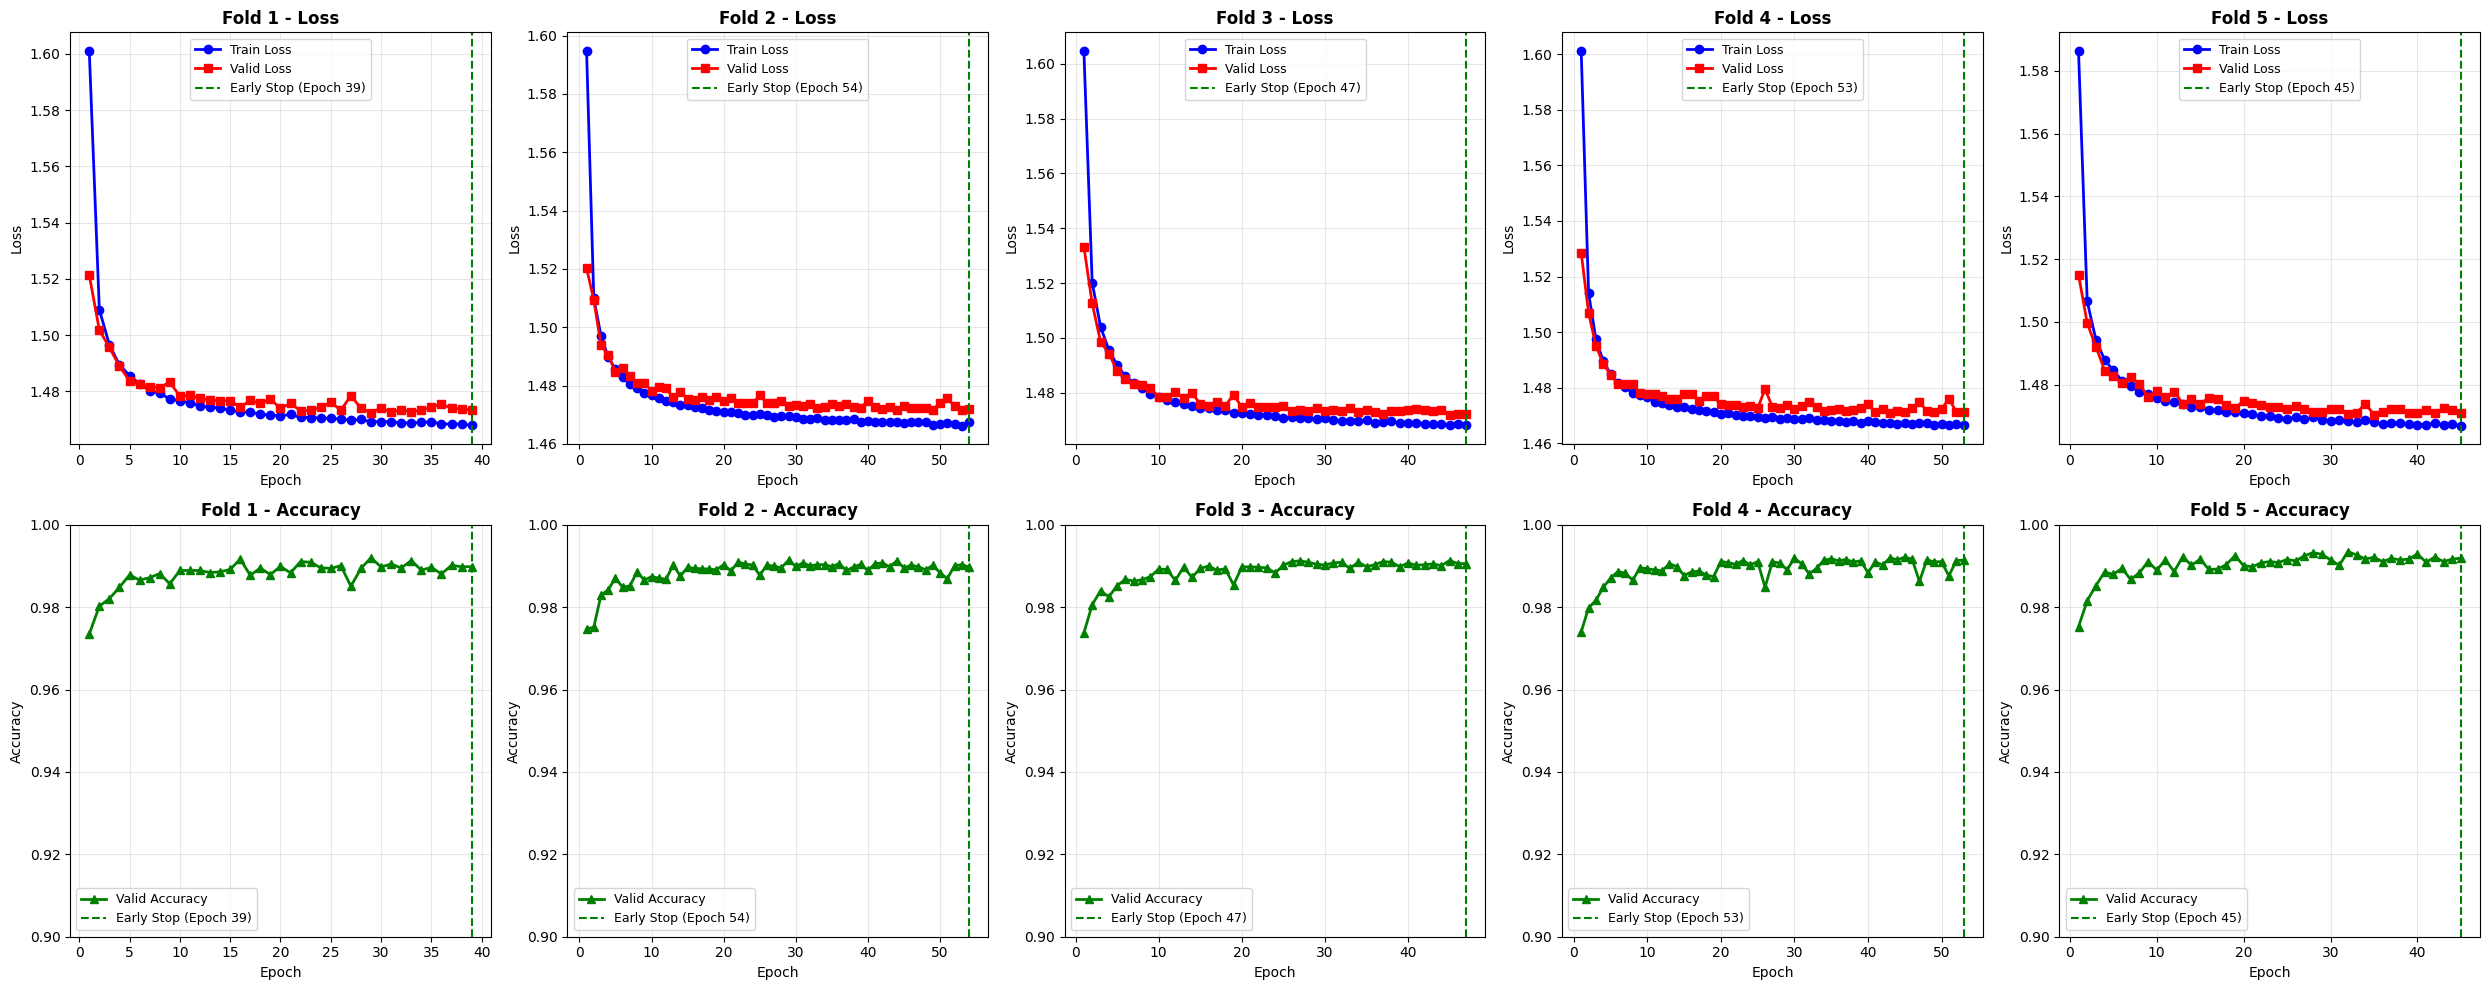

In [131]:
# 各Foldの学習過程を可視化
fig, axes = plt.subplots(2, N_FOLDS, figsize=(5*N_FOLDS, 10))

for i, result in enumerate(fold_results):
    history = result['history']
    epochs = range(1, len(history['train_loss']) + 1)
    stopped_epoch = result['stopped_epoch']
    
    # 損失の推移
    axes[0, i].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
    axes[0, i].plot(epochs, history['valid_loss'], 'r-s', label='Valid Loss', linewidth=2, markersize=6)
    if stopped_epoch < EPOCH:
        axes[0, i].axvline(x=stopped_epoch, color='green', linestyle='--', label=f'Early Stop (Epoch {stopped_epoch})')
    axes[0, i].set_xlabel('Epoch', fontsize=10)
    axes[0, i].set_ylabel('Loss', fontsize=10)
    axes[0, i].set_title(f'Fold {i+1} - Loss', fontsize=12, fontweight='bold')
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    
    # 精度の推移
    axes[1, i].plot(epochs, history['valid_accuracy'], 'g-^', label='Valid Accuracy', linewidth=2, markersize=6)
    if stopped_epoch < EPOCH:
        axes[1, i].axvline(x=stopped_epoch, color='green', linestyle='--', label=f'Early Stop (Epoch {stopped_epoch})')
    axes[1, i].set_xlabel('Epoch', fontsize=10)
    axes[1, i].set_ylabel('Accuracy', fontsize=10)
    axes[1, i].set_title(f'Fold {i+1} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.show()

## テストデータに対する予測

In [133]:
submit = pd.read_csv("../../assets/sample_submit.csv", header=None)
submit.head()

,0,1
0,test_0.jpg,2
1,test_1.jpg,4
2,test_2.jpg,5
3,test_3.jpg,4
4,test_4.jpg,3


In [134]:
# DataSetの形式に合わせるため、ヘッダを少し変更
submit.columns = ["file_name", "category_id"]

In [135]:
test_data = MNIST_data(submit, mode="test", transform=transform_test)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size)

In [136]:
def model_predict(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    with torch.no_grad():
        for data, _ in tqdm.tqdm(input_data):
            data = data.to(device)
            output = input_model(data)
            pred = output.cpu().data.max(1, keepdim=True)[1]
            test_pred = torch.cat((test_pred, pred), dim=0)
    return test_pred

In [137]:
# 最良モデルで予測
# predict = model_predict(best_model, test_loader)

# 1. 各クラスの「確率」を出力する関数を定義
def predict_proba(input_model, data_loader):
    """
    モデルとデータローダーを受け取り、各サンプルのクラス確率を返す関数。
    """
    input_model.eval()
    all_probas = []
    with torch.no_grad():
        for data, _ in tqdm.tqdm(data_loader, desc=f"Predicting Probabilities..."):
            data = data.to(device)
            output = input_model(data)
            
            # モデルの出力（ロジット）をソフトマックス関数で確率に変換
            probas = F.softmax(output, dim=1).cpu()
            all_probas.append(probas)
            
    return torch.cat(all_probas, dim=0)

# 2. 全てのFoldモデルで確率を予測
print("アンサンブル予測を開始します...")
all_fold_predictions = []
for i, model in enumerate(fold_models):
    print(f"Fold {i+1}/{len(fold_models)} のモデルで予測中...")
    probas = predict_proba(model, test_loader)
    all_fold_predictions.append(probas)


# 3. 予測確率を平均化
# all_fold_predictions は [5, num_test_samples, 10] の形状を持つテンソルのリストになる
# これをスタックして平均を取る
stacked_predictions = torch.stack(all_fold_predictions)
mean_predictions = torch.mean(stacked_predictions, dim=0)
print(f"\n予測確率の平均化完了。テンソル形状: {mean_predictions.shape}")

アンサンブル予測を開始します...
Fold 1/5 のモデルで予測中...


Predicting Probabilities...: 100%|██████████| 157/157 [00:02<00:00, 63.78it/s]


Fold 2/5 のモデルで予測中...


Predicting Probabilities...: 100%|██████████| 157/157 [00:01<00:00, 92.21it/s]


Fold 3/5 のモデルで予測中...


Predicting Probabilities...: 100%|██████████| 157/157 [00:01<00:00, 102.09it/s]


Fold 4/5 のモデルで予測中...


Predicting Probabilities...: 100%|██████████| 157/157 [00:01<00:00, 119.32it/s]


Fold 5/5 のモデルで予測中...


Predicting Probabilities...: 100%|██████████| 157/157 [00:01<00:00, 129.74it/s]


予測確率の平均化完了。テンソル形状: torch.Size([10000, 10])


In [138]:
# predict = predict.cpu().detach().numpy().reshape(-1).copy()

# 4. 平均化された確率から最終的なクラスを決定
ensemble_predict = torch.argmax(mean_predictions, dim=1)
predict = ensemble_predict.cpu().detach().numpy().reshape(-1).copy()

In [139]:
submit["category_id"] = predict

In [140]:
submit.head()

,file_name,category_id
0,test_0.jpg,7
1,test_1.jpg,2
2,test_2.jpg,1
3,test_3.jpg,0
4,test_4.jpg,4


In [141]:
# submit.to_csv('../output/submission_capsnet_kfold_earlystop.csv', index=False, header=None)
submit["category_id"] = predict
submission_path = '../../output/submission_capsnet_ensemble.csv'
submit.to_csv(submission_path, index=False, header=None)
print("予測結果を保存しました: ../output/submission_capsnet_kfold_earlystop.csv")

予測結果を保存しました: ../output/submission_capsnet_kfold_earlystop.csv


# まとめ

今回はLeNetの畳み込みステムを活用したCapsule Networkに **K分割交差検証（K-Fold Cross Validation）** と **アーリーストッピング（Early Stopping）** を適用しました.

## アーリーストッピングの特徴

- **過学習の防止**: 検証損失が改善しなくなったら学習を停止
- **計算時間の短縮**: 不要なエポックを実行せず効率的
- **最良モデルの保存**: 検証損失が最小だった時点のモデルを保存

## アーリーストッピングのパラメータ

- **patience**: 何エポック改善しなかったら停止するか（今回: 10）
- **min_delta**: 改善とみなす最小の変化量（今回: 0.0001）
- **mode**: 監視する指標（'min'で損失を監視）

## K-Fold交差検証の特徴

- **データを効率的に活用**: 全データを訓練と検証の両方に使用
- **モデルの汎化性能を正確に評価**: K個の異なる分割で評価することで、偏りの少ない評価が可能
- **過学習の検出**: 各foldでの性能のばらつきから過学習を検出

## Capsule Networkの特徴

- **Primary Capsule Layer**: 畳み込み層の出力をカプセル表現（ベクトル）に変換
- **Digit Capsule Layer**: Dynamic Routingアルゴリズムを用いて各クラスのカプセルを生成
- **Squash関数**: カプセルの長さを0-1の範囲に正規化

## 改善のヒント

- patienceを調整（大きくするとより長く学習）
- min_deltaを調整（小さくするとより細かい改善も検出）
- 学習率のスケジューリング（ReduceLROnPlateauなど）
- データ拡張（回転、平行移動など）を追加

## モデル性能の評価と分析
K-Fold交差検証で最も性能が良かったベストモデルを使い、そのモデルが学習時に見ていない検証データ（Validation Data）に対する性能を詳細に分析します。

In [142]:
# 1. 最良foldの検証データローダーを再作成
# best_fold_idxは学習のサマリーセルで計算済みです
print(f"最良Fold ({best_fold_idx + 1}) の検証データで評価します。")
(_, valid_idx) = list(kfold.split(train_master))[best_fold_idx]
valid_fold_df = train_master.iloc[valid_idx].reset_index(drop=True)
valid_data = MNIST_data(valid_fold_df, mode="train", transform=transform_test)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size)

# 2. 予測の実行
print("最良モデルで検証データの予測を実行します...")
predict_df = predict_img(best_model, valid_loader)
print("完了。")

# 3. 正解率の計算
accuracy = accuracy_score(predict_df["label"], predict_df["predict"])
print(f"最良Foldの検証データに対する正解率: {accuracy:.4f}")

最良Fold (5) の検証データで評価します。
最良モデルで検証データの予測を実行します...


100%|██████████| 188/188 [00:04<00:00, 41.37it/s]


完了。
最良Foldの検証データに対する正解率: 0.9921


混同行列:


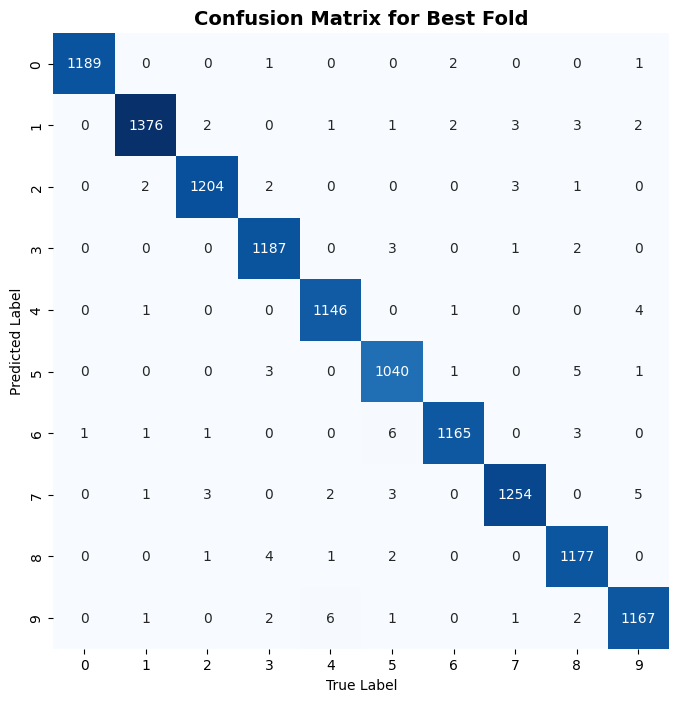

In [143]:
# 4. 混同行列の可視化
print("混同行列:")
plt.figure(figsize=(10, 8))
mat = confusion_matrix(predict_df["label"], predict_df["predict"])
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt="d")
plt.title("Confusion Matrix for Best Fold", fontsize=14, fontweight='bold')
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

間違えた予測の数: 95 / 12000
【予測ミスの分析：ワーストケース（損失が大きい順）】


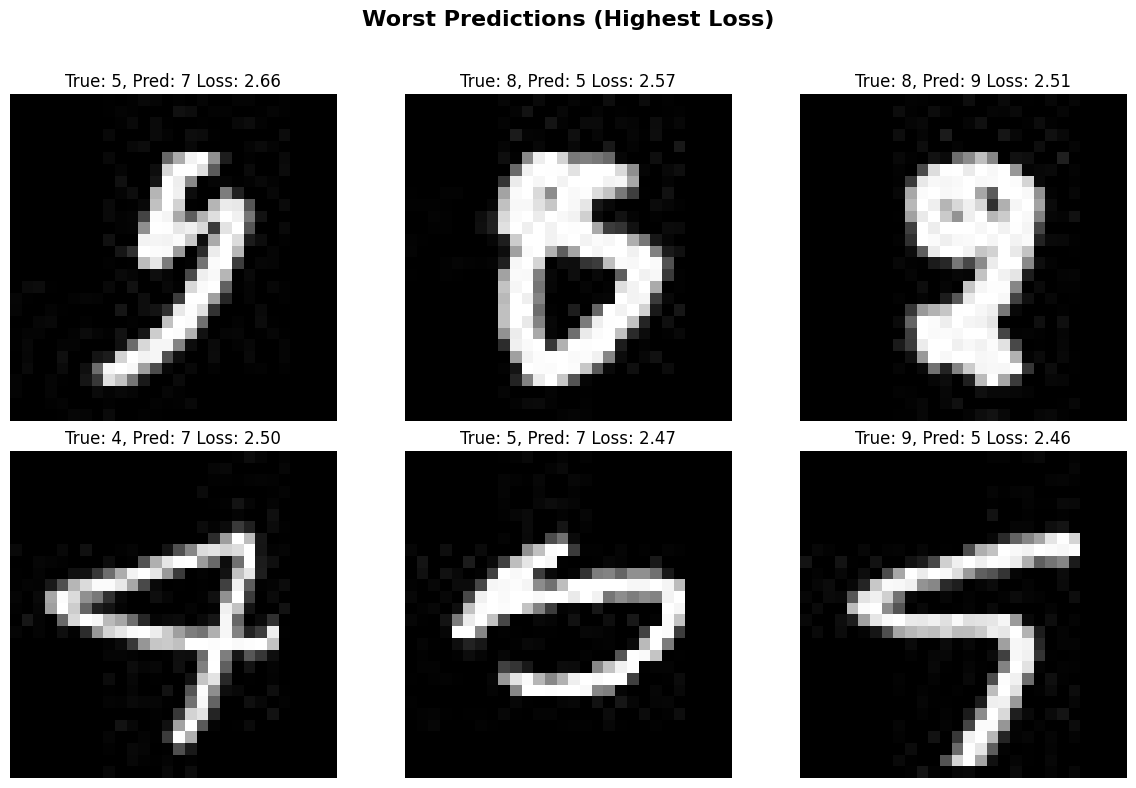

【予測ミスの分析：惜しいケース（損失が小さい順）】


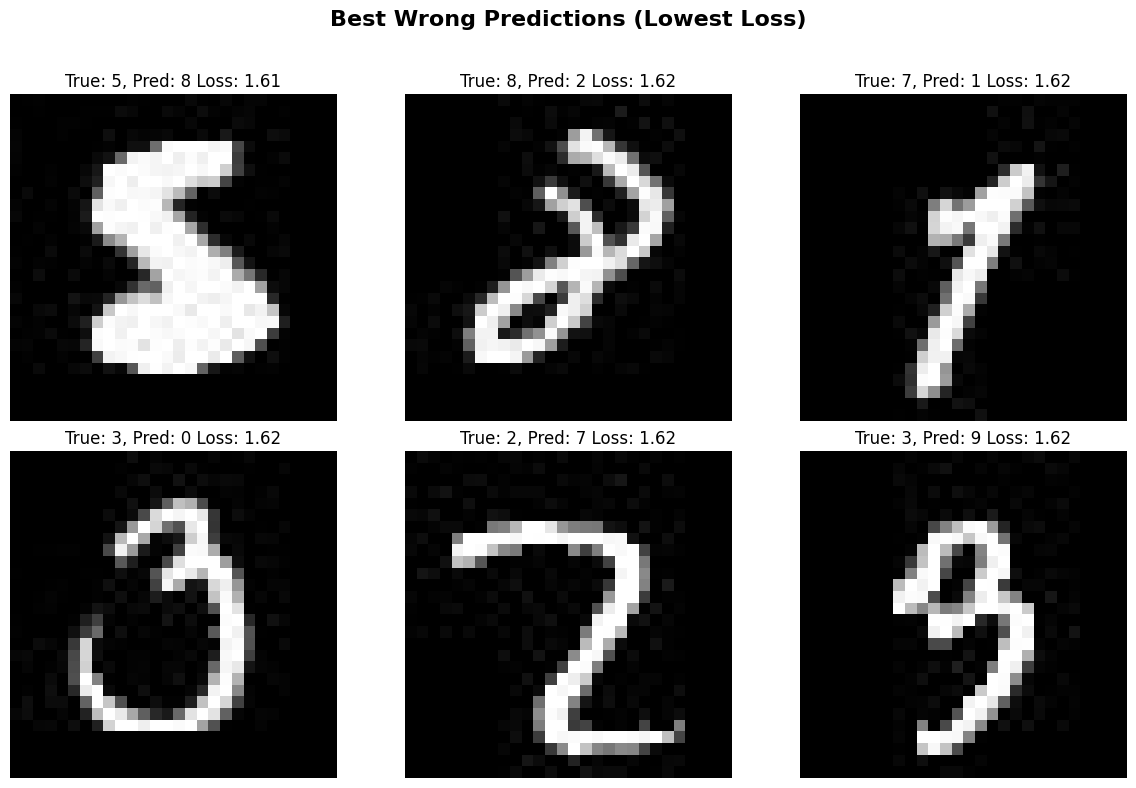

In [144]:
# 5. 間違えた予測の分析
error_df = predict_df[predict_df["label"] != predict_df["predict"]].sort_values(by="loss", ascending=False)

print(f"間違えた予測の数: {len(error_df)} / {len(predict_df)}")

# 損失(loss)が大きい順 = モデルが大きく確信を持って間違えたもの
print("【予測ミスの分析：ワーストケース（損失が大きい順）】")
plt.figure(figsize=(12, 8))
plt.suptitle("Worst Predictions (Highest Loss)", fontsize=16, fontweight='bold')
for i, (ind, row) in enumerate(error_df.head(6).iterrows()):
    label = int(row["label"])
    pred = int(row["predict"])
    loss = row["loss"]
    
    image_name = valid_fold_df.loc[ind, "file_name"]
    image = cv2.imread(f"{train_path}{image_name}", cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {label}, Pred: {pred} Loss: {loss:.2f}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 損失(loss)が小さい順 = 惜しい間違い
print("【予測ミスの分析：惜しいケース（損失が小さい順）】")
best_wrong_df = error_df.sort_values(by="loss", ascending=True)
plt.figure(figsize=(12, 8))
plt.suptitle("Best Wrong Predictions (Lowest Loss)", fontsize=16, fontweight='bold')
for i, (ind, row) in enumerate(best_wrong_df.head(6).iterrows()):
    label = int(row["label"])
    pred = int(row["predict"])
    loss = row["loss"]
    
    image_name = valid_fold_df.loc[ind, "file_name"]
    image = cv2.imread(f"{train_path}{image_name}", cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {label}, Pred: {pred} Loss: {loss:.2f}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()